# Estimating an RBC Model with a Stochastic Trend

Real macro time series have *trends*. US per-capita real GDP, consumption, investment, and the capital stock have all grown at roughly 2% per year for over a century, so the raw data does not fluctuate around a constant mean. The plain RBC model from the previous notebook ({doc}`Fitting an RBC to US Data <fit_rbc_to_us_data>`) has no growth at all — its steady state is a single point, and every endogenous variable is stationary around it. To use that model with real data we had to remove the trend ourselves: log everything, fit a quadratic trend by OLS, and feed the residuals into the Kalman filter. That works, but it has two unattractive features:

1. **It separates trend and cycle by hand.** Any signal the trend regression absorbs is lost to the structural model — the DSGE never sees it, so it can't tell us anything about it.
2. **It commits us to a trend specification that has nothing to do with economics.** A quadratic-in-time trend is convenient but arbitrary; the data did not generate themselves that way.

The cleaner alternative is to let the model itself produce the trend. We add a *stochastic trend* to productivity: a permanent random-walk-with-drift component on top of the usual stationary AR(1) shock. The deterministic drift $g_z$ becomes an estimable parameter — interpretable as "the gross trend growth rate of this economy" — and trend innovations are real, permanent shocks that show up in the impulse response just like any other shock. After a change-of-variables that divides every trending quantity by the permanent productivity level, the model becomes stationary again and we can solve and estimate it with the same Kalman-filter / log-linearization machinery as the textbook RBC. The estimation is now joint: trend growth and business-cycle parameters are recovered together from the raw (logged) data.

A trend alone is not enough, though. A bare RBC with a single TFP shock cannot reproduce the joint dynamics of six macro series at once — there is one source of stochastic variation and six things to explain, so the Kalman filter will inevitably hand most of the action to measurement error. To give the model a fighting chance we add three standard real frictions (consumption habit, quadratic investment adjustment cost, variable capital utilisation) and four more structural shocks (preference, labour-disutility, investment, and utilisation-cost shocks). The result is a six-shock, six-observable model: exactly identified before measurement error, with enough flexibility to capture both the trend and the cycle in the French national-accounts data we'll fit it to.

This notebook walks through the model end-to-end: the equations, the change-of-variables, parser and steady-state checks, then estimation with PyMC.

<div class="alert alert-info" style="
    border: 1px solid #c5d9ea;
    border-left: 5px solid #4a90e2;
    background: #f4f8fb;
    padding: 14px 18px;
    margin: 18px 0;
    border-radius: 4px;
    color: #1f2d3d;">

<div style="font-weight: 600; font-size: 15px; margin-bottom: 6px;">
&#x1F4E6;&nbsp; Notebook prerequisites
</div>

This notebook uses one package that is <em>not</em> a declared dependency of <code>gEconpy</code>. Install it into the same environment before running the cells below:

<pre style="background: #ffffff; border: 1px solid #d6e0ea; padding: 8px 12px; border-radius: 3px; margin: 8px 0; font-size: 13px; overflow-x: auto;">pip install kuznets</pre>

<code>kuznets</code> pulls quarterly French national-accounts and labour-force series from Eurostat&rsquo;s JSON-stat API.
</div>

## Model Equations

### Agents and primitives

A representative household maximises expected discounted **log** utility over consumption and labour. Consumption enters with **external habit** ($\phi_H$), and the labour-disutility weight $\Theta_t$ and the discount factor $\beta_t$ are themselves AR(1) shock processes:

$$
\max_{\{C_t, L_t, I_t, K_t, z_t\}}\;\; E_0 \sum_{t=0}^{\infty} \left(\prod_{s=0}^{t} \beta_s\right)
\left[\log(C_t - \phi_H C_{t-1}) - \Theta_t \, \frac{L_t^{1+\sigma_L}}{1+\sigma_L}\right].
$$

The flow budget constraint and the capital law of motion both pick up new pieces. The household pays a utilisation cost $\Psi(z_t)$ for running its capital harder than steady state, and physical capital is delivered with a quadratic **investment adjustment cost** governed by $\gamma_I$ and the investment-specific shock $\xi^I_t$:

$$
C_t + I_t + \Psi(z_t)\, K_{t-1} \;=\; r_t z_t K_{t-1} + W_t L_t,
$$

$$
K_t \;=\; (1-\delta) K_{t-1} + I_t \left[1 - \frac{\gamma_I}{2} \left(\xi^I_t \, \frac{I_t}{I_{t-1}} - 1 \right)^2\right].
$$

The utilisation-cost function is convex with its own AR(1) shifter $\xi^\psi_t$, and its linear coefficient $\psi_{z,1}$ is pinned to $r^{ss}$ so the steady-state utilisation rate is exactly one:

$$
\Psi(z_t) \;=\; \xi^\psi_t \left[\psi_{z,1}(z_t - 1) + \frac{\psi_z}{2}(z_t - 1)^2\right].
$$

A representative competitive firm produces output with Cobb–Douglas technology, **labour-augmenting** productivity, and **capital services** $K^d_t = z_t K_{t-1}$ that respond to the household's utilisation choice:

$$
Y_t = A_t \, (K^d_t)^{\alpha} \, (Z_t L_t)^{1-\alpha}.
$$

Productivity has two components, one stationary and one non-stationary:

$$
\log A_t = \rho_A \log A_{t-1} + \varepsilon_{A,t}, \qquad
\log Z_t = \log g_z + \log Z_{t-1} + \varepsilon_{z,t}.
$$

$A_t$ is a standard AR(1) wedge that reverts to one. $Z_t$ is a random walk with drift $\log g_z$, so it has a unit root and any innovation $\varepsilon_{z,t}$ *permanently* shifts the productivity level. The deterministic drift $g_z$ is the gross trend growth rate of the economy.

### The full set of structural shocks

There are six exogenous AR(1) wedges:

| Shock           | State           | Reverts to | Acts on                              |
|-----------------|-----------------|------------|---------------------------------------|
| $\varepsilon_{A,t}$       | $A_t$       | $1$       | Stationary TFP wedge in production    |
| $\varepsilon_{z,t}$       | $G_t$       | $g_z$     | Trend growth rate of productivity     |
| $\varepsilon_{\beta,t}$   | $\beta_t$   | $\beta$   | Discount factor / inter-temporal preference |
| $\varepsilon_{\Theta,t}$  | $\Theta_t$  | $\Theta$  | Weight on labour disutility            |
| $\varepsilon_{I,t}$       | $\xi^I_t$   | $1$       | Investment adjustment cost            |
| $\varepsilon_{\psi,t}$    | $\xi^\psi_t$| $1$       | Capital utilisation cost              |

With six observables ($Y$, $C$, $I$, $L$, $w$, $r$) and six shocks the state space is exactly identified — measurement error is now a modelling choice, not a structural requirement.

### Why we cannot solve this directly

Because $Z_t$ has a unit root, every level variable that uses it as an input — $Y_t$, $C_t$, $I_t$, $K_t$, $W_t$ — is non-stationary. The model has no point steady state in levels: it has a *balanced growth path* (BGP) on which all of these variables grow at rate $g_z$. The linear perturbation tools `gEconpy` uses (and the Kalman filter, for that matter) require a stationary system. We therefore rewrite the model in deviations from the BGP by performing a change-of-variables.

### Change-of-variables

Define growth-adjusted (stationary) versions of each trending quantity by dividing through by $Z_t$:

$$
y_t \equiv \frac{Y_t}{Z_t}, \quad
c_t \equiv \frac{C_t}{Z_t}, \quad
i_t \equiv \frac{I_t}{Z_t}, \quad
k_t \equiv \frac{K_t}{Z_t}, \quad
w_t \equiv \frac{W_t}{Z_t}.
$$

$L_t$, $r_t$, $A_t$, $z_t$, and all of the shock states are already stationary. The only piece of the trend that survives the transformation is the gross growth rate

$$
G_t \equiv \frac{Z_t}{Z_{t-1}}, \qquad \log G_t = \log g_z + \varepsilon_{z,t},
$$

so $Z_t$ itself never appears in the stationary model — only $G_t$ does. Applying the transformation to each equation gives the form actually written in the GCN file:

**Production.**

$$
y_t = A_t \, L_t^{1-\alpha} \, \left(\frac{z_t \, k_{t-1}}{G_t}\right)^{\alpha}.
$$

The factor $1/G_t$ appears because predetermined capital was scaled by *yesterday's* $Z$, but today's production uses *today's* $Z$.

**Capital LOM with adjustment cost.**

$$
k_t \;=\; (1-\delta)\,\frac{k_{t-1}}{G_t} + i_t \left[1 - \frac{\gamma_I}{2}\left(\xi^I_t \, \frac{i_t}{i_{t-1}} G_t - g_z\right)^2\right].
$$

Subtracting $g_z$ inside the quadratic centres the friction on the BGP investment growth rate, so the cost is exactly zero in steady state.

**Budget constraint with utilisation cost.**

$$
c_t + i_t + \Psi(z_t)\, \frac{k_{t-1}}{G_t} \;=\; r_t z_t \, \frac{k_{t-1}}{G_t} + w_t L_t.
$$

**Stochastic Euler equation** (this is what the parser will derive from the household's Bellman, with habit and the time-varying $\beta_t$ folded in):

$$
\lambda_t \;=\; \beta_t \, E_t\!\left[\lambda_{t+1} \cdot \frac{r_{t+1} z_{t+1} - \Psi(z_{t+1}) + (1-\delta)\, q_{t+1}/\lambda_{t+1}}{G_{t+1}}\right],
$$

where $\lambda_t$ is the budget-constraint multiplier and $q_t$ the Tobin's-$q$ multiplier on the capital LOM. Habit makes $\lambda_t$ depend on both current and lagged consumption.

### Why log utility?

With separable additive CRRA preferences

$$ u(C, L) = \frac{C^{1-\sigma_C}}{1-\sigma_C} - \frac{L^{1+\sigma_L}}{1+\sigma_L},$$

the change-of-variables introduces a $Z_t^{1-\sigma_C}$ factor inside the discounted sum that does *not* drop out of the FOCs unless $\sigma_C = 1$. King, Plosser, and Rebelo (1988) showed that BGP-compatible preferences either take the log form used here or a non-separable "KPR" form. Log utility is the simplest choice, and the only thing that changes when we layer habit and time-varying $\beta_t / \Theta_t$ on top is that the FOCs pick up extra terms — the BGP-compatibility argument is unaffected.

### Steady state

At the BGP we set $A = 1$, $G = g_z$, $z = 1$, all shock states equal to one, and constant lowercase variables. The frictions all vanish (zero adjustment-cost residual, zero utilisation cost), and the Euler equation collapses to

$$
r^{ss} \;=\; \frac{g_z}{\beta} - (1 - \delta),
$$

unchanged from the frictionless growth model. The capital law of motion gives

$$
\frac{i^{ss}}{k^{ss}} \;=\; \frac{g_z - 1 + \delta}{g_z},
$$

i.e., on the BGP, investment must cover both depreciation *and* the "dilution" of $k = K/Z$ caused by growth in the denominator. The marginal utility of consumption now reflects habit:

$$
\lambda^{ss} \;=\; \frac{1 - \phi_H \beta / g_z}{C^{ss}\,(1 - \phi_H/g_z)}.
$$

The remaining ratios $k/L$, $y/L$, $c/L$, $w$, and the implied $L^{ss}$ follow from the firm's first-order conditions, the resource constraint, and the labour-supply FOC with the habit-adjusted $\lambda^{ss}$. Closed forms for all sixteen steady-state quantities are given in the `STEADY_STATE` block of the GCN file.

In [1]:
import arviz as az
import arviz_plots as azp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import preliz as pz
import pymc as pm

import gEconpy as ge
import gEconpy.plotting as gp

gp.set_matplotlib_style()

In [2]:
RANDOM_SEED = sum(map(ord, "RBC with Growth"))
rng = np.random.default_rng(RANDOM_SEED)

## Loading the Model

The growth-adjusted equations above are encoded in `RBC_with_growth.gcn`. `gEconpy` parses the file, derives the household and firm first-order conditions symbolically, and exposes a `Model` (for solving / simulating / IRFs) or a `PyMCStateSpace` (for Kalman-filter estimation in PyMC). Let's first print the file so the model is in plain sight as we work through it.

In [3]:
gcn_path = "../GCN Files/RBC_with_growth.gcn"
ge.print_gcn_file(gcn_path)

In [4]:
mod = ge.model_from_gcn(gcn_path, verbose=True)

Model Building Complete.
Found:
	17 equations
	17 variables
		The following variables were eliminated at user request:
			K_d_t, TC_t, U_t
		The following "variables" were defined as constants and have been substituted away:
			mc_t
	6 stochastic shocks
		 0 / 6 have a defined prior.
	14 parameters
		 13 / 14 have a defined prior.
	0 parameters to calibrate.
	17 / 17 variables have analytical steady-state values.
		17 user-provided: A_ss, C_ss, G_ss, I_ss, K_ss, L_ss, R_f_ss, 
                                  Theta_ss, W_ss, Y_ss, beta_ss, lambda_ss, 
                                  q_ss, r_ss, shock_I_ss, shock_psi_ss, z_ss
Model appears well defined and ready to proceed to solving.



## The Steady State

The steady state is the long-run point around which the linearised model lives — the BGP values of every variable once trend growth has been factored out. Before we fit anything, it's worth doing two sanity checks:

1. **Inspect the steady state at the calibrated parameter values** to make sure the numbers are economically sensible (positive consumption, $r^{ss}$ in a plausible range, an investment-to-output ratio that matches what we'd expect for an advanced economy, etc.).
2. **Propagate the prior uncertainty in the parameters to the steady state**, so we can see what range of long-run worlds our prior actually contemplates. Each prior draw gives a different set of parameters; for each set we can solve the closed-form steady state in the `STEADY_STATE` block. The marginal distributions of the resulting steady-state values tell us whether the priors are tight enough to be informative, or whether they cover such a wide range that the data will have to do all the work.

### At the initial calibration

In [5]:
ss_init = mod.steady_state(verbose=False, progressbar=False)
pd.Series(dict(ss_init), name="value").round(4).to_frame()

,value
A_ss,1.0000
C_ss,1.7838
G_ss,1.0050
I_ss,0.5153
K_ss,17.2641
L_ss,0.9710
R_f_ss,0.0152
Theta_ss,1.0000
W_ss,1.6574
Y_ss,2.2991


A quick sanity scan:

- $r^{ss} \approx 0.040$ per quarter ($\approx 16\%$ annualised) — high for modern Europe, driven by $\beta = 0.99$ and $\delta = 0.025$. Estimation will pull both of these.
- $L^{ss} \approx 0.97$ — close to one. With $\Theta = 1$ and no scaling, the household supplies nearly all of its time; this is why the data needs the Hansen-style rescaling we'll apply below.
- $i^{ss}/y^{ss} \approx 0.26$ and $c^{ss}/y^{ss} \approx 0.74$ — standard RBC investment- and consumption-output ratios.
- All shock states and the utilisation rate are exactly one at the BGP, by construction. The frictions vanish.

### Under the prior

A single steady state is a single point. The priors define a whole *distribution* over plausible long-run worlds. We can visualise that distribution by sampling from the prior, evaluating the closed-form steady-state mapping at each draw, and looking at the marginal density of each steady-state quantity. Vertical lines mark the initial-calibration values.

In [6]:
ss_mod = ge.statespace_from_gcn(gcn_path, not_loglin_variables=["R_f"])

Model Building Complete.
Found:
	17 equations
	17 variables
		The following variables were eliminated at user request:
			K_d_t, TC_t, U_t
		The following "variables" were defined as constants and have been substituted away:
			mc_t
	6 stochastic shocks
		 0 / 6 have a defined prior.
	14 parameters
		 13 / 14 have a defined prior.
	0 parameters to calibrate.
	17 / 17 variables have analytical steady-state values.
		17 user-provided: A_ss, C_ss, G_ss, I_ss, K_ss, L_ss, R_f_ss, 
                                  Theta_ss, W_ss, Y_ss, beta_ss, lambda_ss, 
                                  q_ss, r_ss, shock_I_ss, shock_psi_ss, z_ss
Model appears well defined and ready to proceed to solving.



Statespace model construction complete, but call the .configure method to finalize.


In [7]:
from pytensor.graph.replace import graph_replace

prior_dict = ss_mod.param_priors.copy()

with pm.Model(coords=ss_mod.coords) as m:
    ss_mod.to_pymc()
    # Tight Normal centred on the Theta implied by the observed labour mean:
    # Theta ~ 157 gives L_ss = exp(mean(log_L)) ~ 0.18.
    d = pz.Normal(mu=157.0, sigma=20.0)
    prior_dict["Theta"] = d
    d.to_pymc("Theta")

    replacement_dict = {var: m[name] for name, var in ss_mod._name_to_variable.items() if name in m.named_vars}
    for key, value in ss_mod.steady_state_mapping.items():
        pm.Deterministic(key.name, graph_replace(value, replacement_dict, strict=False))
    prior_idata = pm.sample_prior_predictive(random_seed=RANDOM_SEED)

deterministic_ss = ["A_ss", "shock_I_ss", "shock_psi_ss", "z_ss"]
ss_prior = prior_idata.prior.to_dataset()[list(mod.steady_state().keys())]

Sampling: [Theta, alpha, beta, delta, g_z, gamma_I, phi_H, psi_z, rho_A, rho_I, rho_Theta, rho_beta, rho_psi, sigma_L]


In [8]:
ss_prior_df = az.summary(ss_prior, var_names=[f"~{x}" for x in deterministic_ss]).drop(columns=["r_hat"])
ss_prior_df

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,mcse_mean,mcse_sd
C_ss,0.6,0.2,0.28,0.94,513,483,0.009,0.0068
G_ss,1.0049,0.0021,1,1,476,396,9.7e-05,7e-05
I_ss,0.13,0.063,0.047,0.24,570,502,0.0026,0.0031
K_ss,4.4,2.5,1.5,8.9,493,480,0.11,0.11
L_ss,0.378,0.113,0.19,0.55,546,412,0.0048,0.003
R_f_ss,0.0243,0.0106,0.011,0.043,495,477,0.00048,0.00047
Theta_ss,157,20,130,190,578,449,0.81,0.64
W_ss,1.4,0.2,1.1,1.8,556,500,0.0087,0.0084
Y_ss,0.73,0.26,0.33,1.2,523,483,0.011,0.0093
beta_ss,0.9812,0.0099,0.96,0.99,483,433,0.00044,0.00045


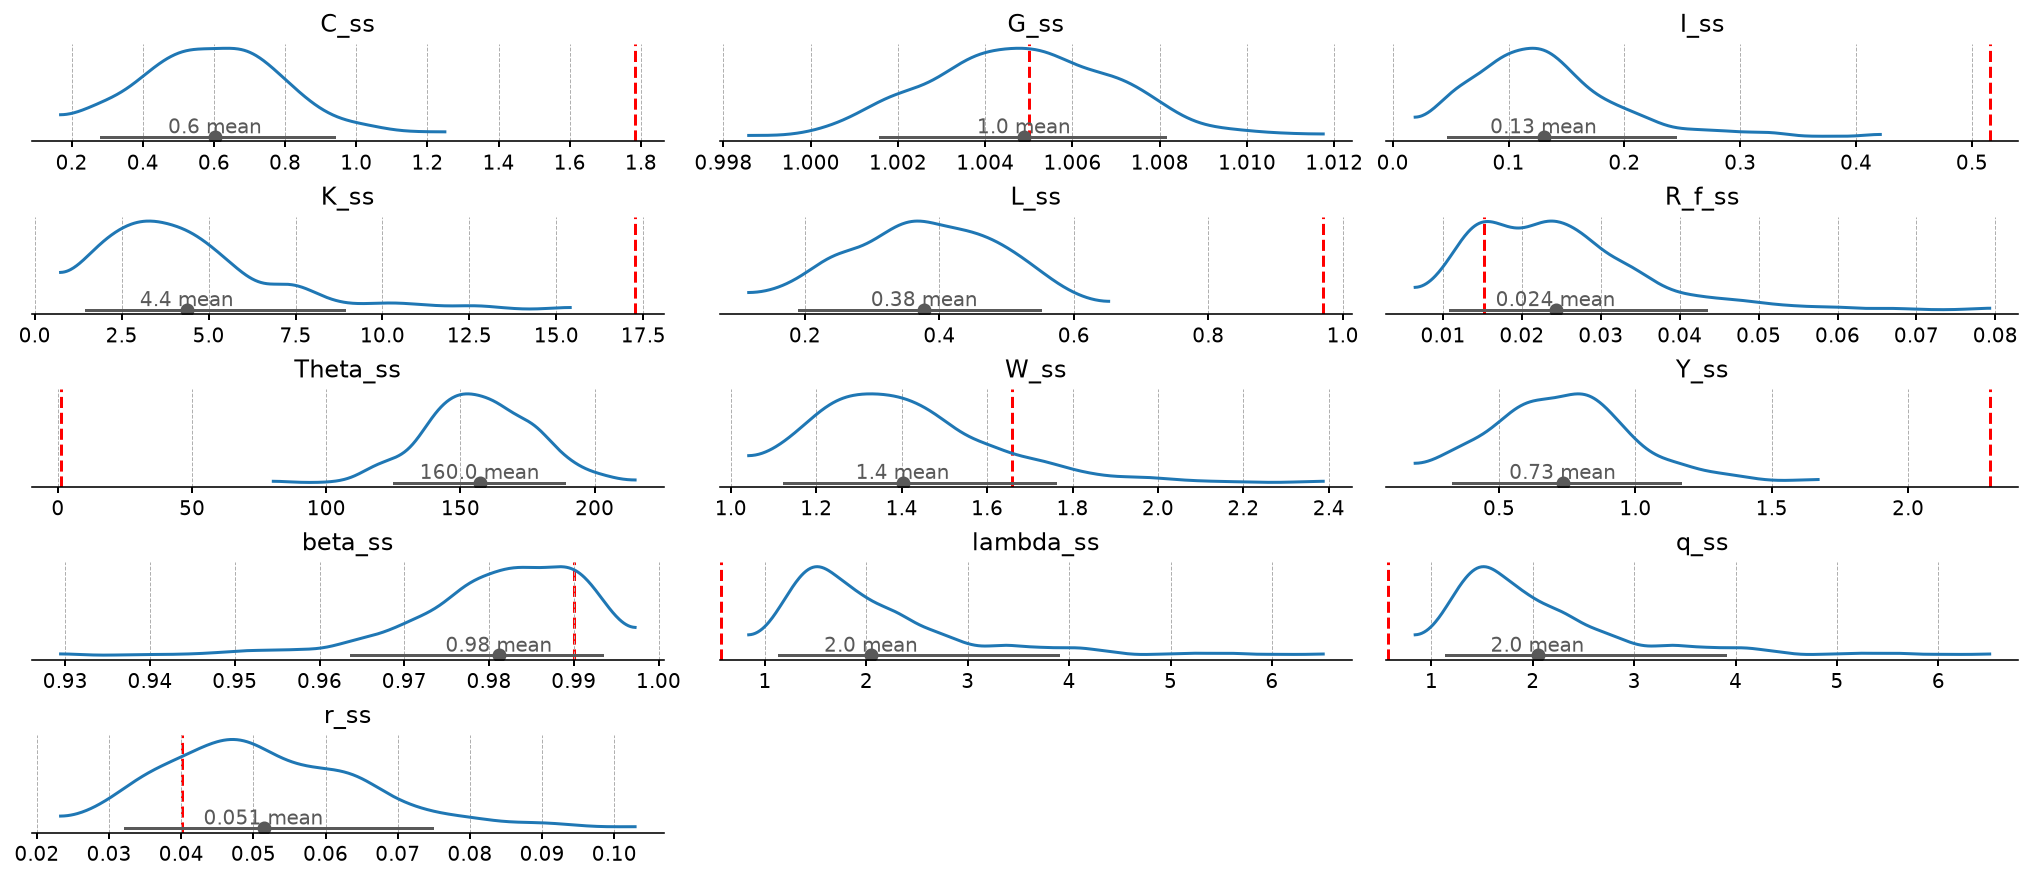

In [9]:
ss_to_plot = [n for n in ss_prior.data_vars if float(ss_prior[n].std()) > 1e-6]
ss_init_dict = {n: float(ss_init[n]) for n in ss_to_plot}

pc = azp.plot_dist(
    ss_prior,
    var_names=ss_to_plot,
    col_wrap=3,
    figure_kwargs={"figsize": (14, 6)},
)
azp.add_lines(pc, ss_init_dict, visuals={"ref_line": {"color": "red", "linestyle": "--"}})
pc.show()

A few observations the plots make obvious:

- **$\Theta^{ss}$ vs $L^{ss}$.** The initial calibration sits in the lower tail of $\Theta^{ss}$ and in the upper tail of $L^{ss}$. That is not an accident — $\Theta$ and $L^{ss}$ are inversely related through the labour-supply FOC, so any prior draw that pushes $\Theta$ up pulls $L^{ss}$ down. Both initial values look extreme relative to the prior, which is the formal expression of the Hansen-rescaling argument from earlier: the data lives near $L \approx 0.18$, so the prior is going to want a much heavier $\Theta$ than the calibration starts with.
- **$r^{ss}$.** Initial value is on the low side of the prior — the prior contemplates `r_ss` between 2% and 12% per quarter (annualised: 8% to 60%). Reality is closer to 1–3% annually, and we'll let the estimation pull `beta` toward 1 and `delta` toward small values to get there.
- **$G^{ss}$.** Tight, symmetric, centred on $g_z = 1.005$. The prior on trend growth is informative; the data will refine it but won't overturn it.
- **$\beta^{ss}$.** The prior is heavily right-skewed by construction (`Beta` with a lot of mass near $0.99$), so the initial value $0.99$ is at the upper tail.

Together this is a fine prior to take to the data: tight enough to rule out absurd long-run worlds (negative consumption, $L^{ss} > 1$ that would mean working more than a full day), wide enough that the data has somewhere to move us.

## French Data from Eurostat

Eurostat publishes quarterly French national accounts (real GDP and its expenditure components in chain-linked 2015 euros) as well as quarterly labour-input data measured in *hours actually worked*. That is exactly what the model wants: $L_t$ in the GCN is a labour input that, dimensionally, is hours per period, so we can build a clean hours-per-capita series directly.

`kuznets` reads Eurostat's JSON-stat API. Each dataset is identified by a short code (e.g. `namq_10_gdp` for national-accounts main aggregates). Its `EurostatReader` downloads a whole dataset, and `namq_10_gdp` unfiltered is far above the API's extraction limit, so the small subclass below passes the dimension filters (geography, seasonal adjustment, unit, accounting item, NACE branch) to the API as query parameters.

We pull:

| Symbol      | Eurostat dataset  | Filter / interpretation                                                  |
|-------------|-------------------|---------------------------------------------------------------------------|
| $Y$         | `namq_10_gdp`     | Real GDP, chain-linked 2015 M€, SCA                                       |
| $C$         | `namq_10_gdp`     | Real household + NPISH final consumption, chain-linked 2015 M€, SCA       |
| $I$         | `namq_10_gdp`     | Real gross fixed capital formation, chain-linked 2015 M€, SCA             |
| `L_hours`   | `namq_10_a10_e`   | Total hours worked, thousand hours, SCA                                   |
| $N$         | `lfsq_pganws`     | Working-age population 15–64, thousand persons                            |
| `D1`        | `namq_10_a10`     | Compensation of employees, nominal M€, SA                                 |
| $P$         | `namq_10_gdp`     | GDP deflator, index 2015 = 100, SCA                                       |
| `i_nom`     | `irt_lt_mcby_q`   | 10-year French government bond yield, annualised percent                  |

Derived series:

$$
L \;=\; \frac{L_{\text{hours}}}{N \cdot 16 \cdot \text{days in quarter}}
$$

$L$ expresses total hours worked as a fraction of the $16$ *waking* hours per day per working-age person (the convention from Hansen 1985 — people have to sleep), which puts it on the same dimensionless $[0, 1]$ scale as the model's $L^{ss}$. Days per quarter are computed exactly so leap-year drift (Q1 has 90 vs 91 days) does not leak into the labour series.

$$
w \;=\; \frac{D_1 / L_{\text{hours}}}{P / 100}
$$

The real wage is nominal compensation per hour worked, deflated by the GDP deflator at 2015 prices.

$$
r \;=\; \frac{\left(1 + i_t^{\text{nom}}/100\right)^{1/4}}{1 + \pi_t} - 1, \qquad \pi_t = \frac{\Delta P_t}{P_{t-1}}
$$

The quarterly real rate from Fisher: annualised 10-year yield converted to quarterly, deflated by quarterly inflation from the GDP deflator.

In [10]:
from pathlib import Path

from kuznets.eurostat import EurostatReader


class FilteredEurostatReader(EurostatReader):
    """Eurostat reader that narrows the extraction to one series with dimension filters."""

    def __init__(self, dataset, filters, **kwargs):
        super().__init__(dataset, **kwargs)
        self.filters = filters

    @property
    def params(self):
        return {**super().params, **self.filters}


def es_series(dataset, name, **filters):
    """Pull a single Eurostat time series and return a named ``pd.Series``.

    ``filters`` are dimension codes (``geo="FR"``, ``na_item="B1GQ"``, ...) sent to the API as query
    parameters, so only the requested series is downloaded.
    """
    df = FilteredEurostatReader(dataset, filters, start="1950", end="2030").read()
    if df.shape[1] != 1:
        raise ValueError(f"{dataset} returned {df.shape[1]} series for {name}; tighten filters: {filters}")
    s = df.iloc[:, 0]
    s.name = name
    return s


cache_path = Path("fr_eurostat_data.csv")
required = ["Y", "C", "I", "L_hours", "N", "D1", "P", "i_nom"]
need_refresh = True
if cache_path.exists():
    data = pd.read_csv(cache_path, index_col=0, parse_dates=[0])
    need_refresh = not set(required).issubset(data.columns)

if need_refresh:
    data = pd.concat(
        [
            es_series("namq_10_gdp", "Y", geo="FR", s_adj="SCA", unit="CLV15_MEUR", na_item="B1GQ"),
            es_series("namq_10_gdp", "C", geo="FR", s_adj="SCA", unit="CLV15_MEUR", na_item="P31_S14_S15"),
            es_series("namq_10_gdp", "I", geo="FR", s_adj="SCA", unit="CLV15_MEUR", na_item="P51G"),
            es_series(
                "namq_10_a10_e", "L_hours", geo="FR", s_adj="SCA", nace_r2="TOTAL", na_item="EMP_DC", unit="THS_HW"
            ),
            es_series("namq_10_a10", "D1", geo="FR", s_adj="SA", nace_r2="TOTAL", na_item="D1", unit="CP_MEUR"),
            es_series("namq_10_gdp", "P", geo="FR", s_adj="SCA", unit="PD15_EUR", na_item="B1GQ"),
            es_series(
                "lfsq_pganws", "N", geo="FR", age="Y15-64", sex="T", citizen="TOTAL", wstatus="POP", unit="THS_PER"
            ),
            es_series("irt_lt_mcby_q", "i_nom", geo="FR", int_rt="MCBY"),
        ],
        axis=1,
    )
    data.index.name = "Time"
    data.to_csv(cache_path)

data.tail()

,Y,C,I,L_hours,D1,P,N,i_nom
Time,,,,,,,,
2025-01-01,615341.9,329412.8,133012.2,11555800.0,381012.9,120.120,41354.5,3.30500
2025-04-01,617501.9,329332.3,133526.0,11543600.0,382597.8,120.174,41371.6,3.25341
2025-07-01,620923.5,329660.8,134567.3,11550900.0,384013.7,120.565,41392.8,3.43000
2025-10-01,622228.7,330832.7,134988.3,11542600.0,386328.9,121.106,41414.4,3.44000
2026-01-01,622197.9,330450.4,134487.8,NaN,NaN,NaN,NaN,3.52744


In [11]:
print("Raw coverage:")
for col in data:
    s = data[col].dropna()
    print(f"  {col:8s}  {s.index.min().date()} -> {s.index.max().date()}  ({len(s)} obs)")

Raw coverage:
  Y         1980-01-01 -> 2026-01-01  (185 obs)
  C         1980-01-01 -> 2026-01-01  (185 obs)
  I         1980-01-01 -> 2026-01-01  (185 obs)
  L_hours   1980-01-01 -> 2025-10-01  (184 obs)
  D1        1980-01-01 -> 2025-10-01  (184 obs)
  P         1980-01-01 -> 2025-10-01  (184 obs)
  N         1998-01-01 -> 2025-10-01  (97 obs)
  i_nom     1980-01-01 -> 2026-01-01  (185 obs)


In [12]:
df = pd.DataFrame(index=data.index)

df["Y"] = data["Y"]
df["C"] = data["C"]
df["I"] = data["I"]

ACTIVE_HOURS_PER_DAY = 16
period = data.index.to_period("Q")
days_in_quarter = (period.asfreq("D", "end").to_timestamp() - period.asfreq("D", "start").to_timestamp()).days + 1
df["L"] = data["L_hours"] / data["N"] / (ACTIVE_HOURS_PER_DAY * days_in_quarter)

# Real wage: nominal compensation per hour, deflated by the GDP deflator
# (base 2015 = 100).
df["w"] = (data["D1"] / data["L_hours"]) / (data["P"] / 100.0)

# Quarterly real rate from Fisher: annualised 10y yield -> quarterly, deflated
# by quarterly inflation from the GDP deflator.
pi_q = data["P"].pct_change()
i_q = (1.0 + data["i_nom"] / 100.0) ** 0.25 - 1.0
df["r"] = (1.0 + i_q) / (1.0 + pi_q) - 1.0

df = df[["Y", "C", "I", "L", "w", "r"]].dropna(how="all")
df.index.freq = "QS"
df.tail()

,Y,C,I,L,w,r
Time,,,,,,
2025-01-01,615341.9,329412.8,133012.2,0.194050,0.027449,0.004561
2025-04-01,617501.9,329332.3,133526.0,0.191636,0.027580,0.007583
2025-07-01,620923.5,329660.8,134567.3,0.189576,0.027575,0.005196
2025-10-01,622228.7,330832.7,134988.3,0.189341,0.027637,0.003986
2026-01-01,622197.9,330450.4,134487.8,NaN,NaN,NaN


### Raw series

The six series, untouched. The big picture: $Y$, $C$, $I$, and $w$ trend strongly upwards (they inherit the unit root in productivity); $L$ and $r$ look stationary.

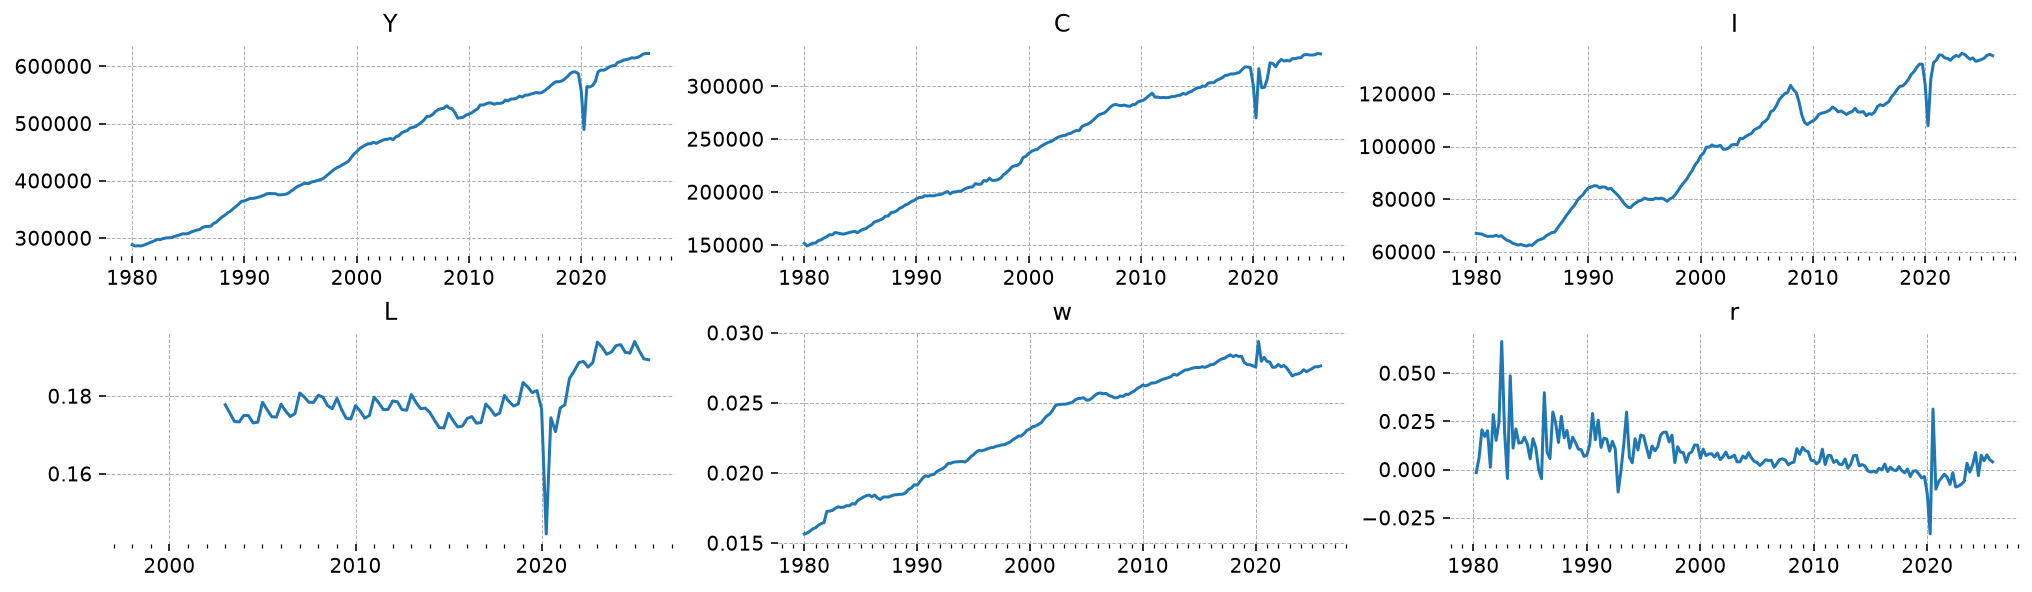

In [13]:
gp.plot_timeseries(df, n_cols=3, fig_kwargs={"figsize": (14, 4)});

### Preprocessing for the Kalman filter

The linearized model has stationary states — $\hat y_t$, $\hat c_t$, $\hat L_t$, etc., all in log-deviations from steady state — and we need to feed it stationary observables. Two transformations cover all six series:

- **Trending real-side variables** ($Y$, $C$, $I$, $w$). These inherit the unit root in $Z_t$, so we take the first difference of the log to convert them into quarterly real growth rates. In the model, $\Delta \log Y_t = \log G_t + \Delta \hat{y}_t$, and because $\log G_t$ has long-run mean $\log g_z$, the *long-run mean* of each transformed series is the single model parameter $\log g_z$.
- **Naturally stationary variables** ($L$, $r$). $L$ is hours per working-age person; we log it. $r$ is already a quarterly real rate, so we leave it on the decimal scale. Their long-run means are $\log L^{ss}$ and $r^{ss}$ respectively.

Critically, we do **not** subtract sample means or fit a deterministic trend. `gEconpy` supports putting the model's steady state directly into the observation-equation intercepts — so for every observable, the mean of the data lines up against a single model number ($\log g_z$, $\log L^{ss}$, or $r^{ss}$). The estimation procedure then treats deviations from those steady-state means as informative about the structural parameters, instead of throwing them away in a preprocessing step.

In [14]:
df_obs = pd.DataFrame(index=df.index)

# Trending real-side variables: log + first difference -> quarterly real growth rates.
# Column names encode the transformation (`dlog_X`) and are deliberately distinct
# from the latent-state names (Y, C, I, W) that appear in the GCN.
for col, name in [("Y", "dlog_Y"), ("C", "dlog_C"), ("I", "dlog_I"), ("w", "dlog_W")]:
    df_obs[name] = np.log(df[col]).diff()

# Stationary variables.  log_L is observed in logs; the real interest rate maps
# onto the model's net risk-free rate R_f (a level, not a log).
df_obs["log_L"] = np.log(df["L"])
df_obs["R_f"] = df["r"]

df_obs = df_obs.dropna(how="all")
df_obs.describe()

,dlog_Y,dlog_C,dlog_I,dlog_W,log_L,R_f
count,184.000000,184.000000,184.000000,183.000000,97.000000,183.000000
mean,0.004174,0.004232,0.003785,0.003108,-1.721223,0.007613
std,0.015697,0.016851,0.019370,0.008499,0.039445,0.010591
min,-0.129838,-0.108797,-0.134123,-0.049190,-1.934368,-0.033394
25%,0.001593,0.000756,-0.002873,0.000461,-1.742982,0.001986
50%,0.004425,0.004226,0.004512,0.003426,-1.728491,0.006082
75%,0.007129,0.007909,0.011448,0.005755,-1.709883,0.011844
max,0.142350,0.158507,0.152297,0.064056,-1.639637,0.066406


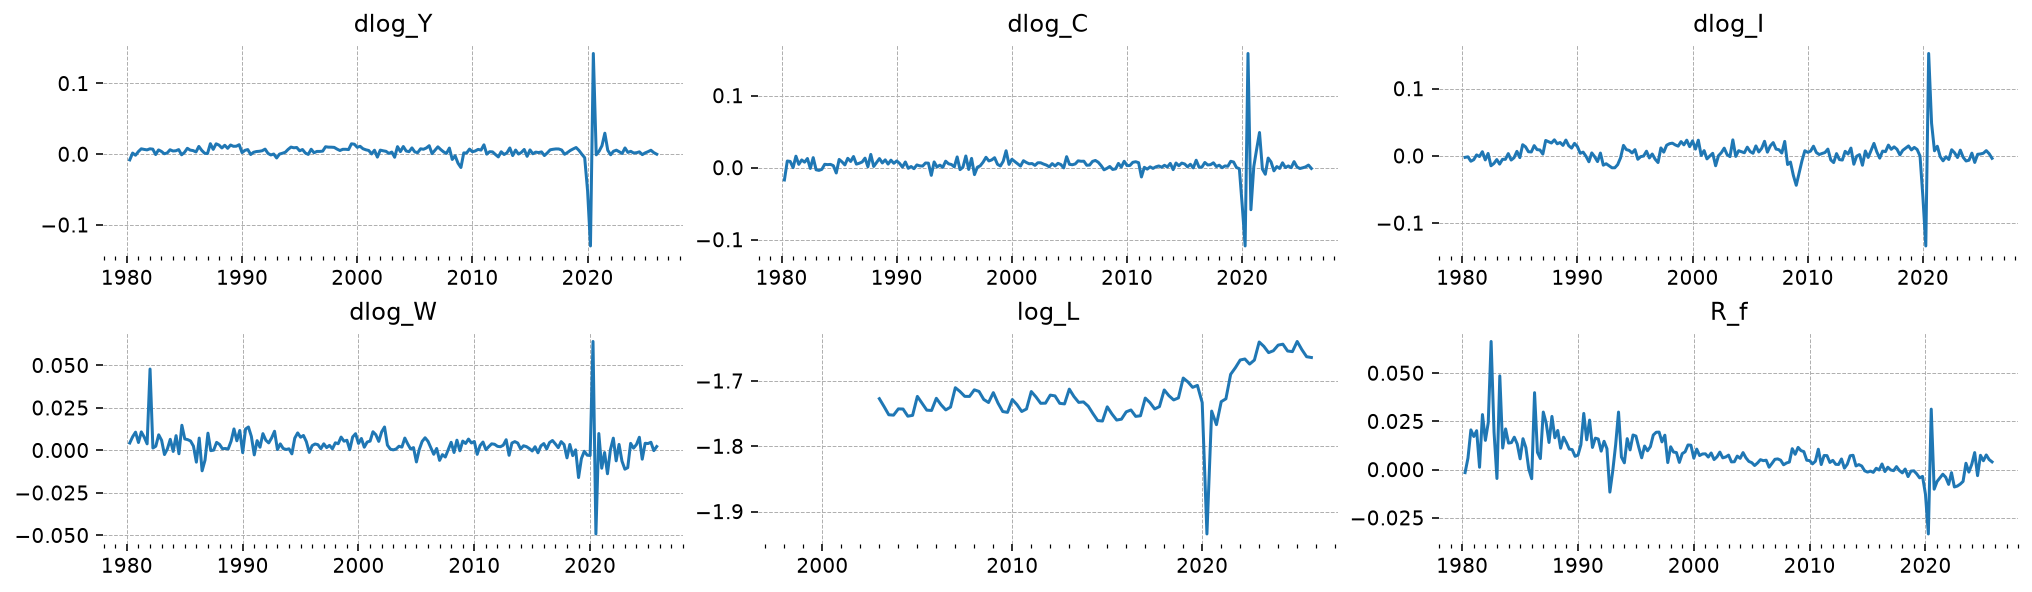

In [15]:
gp.plot_timeseries(df_obs, n_cols=3, fig_kwargs={"figsize": (14, 4)});

### Masking the COVID-19 quarters

The six panels above share a feature that will wreck the estimation if we ignore it: the 2020 spikes. French real GDP fell 13.5% in 2020 Q2 and rebounded 18.5% in Q3 — and consumption, investment, hours, and the wage all moved with it. In the transformed `dlog_*` series these quarters are **6-to-9-standard-deviation events** relative to the rest of the sample.

A Gaussian Kalman filter has no way to treat such observations as the rare draws they are. Its likelihood penalises a prediction error quadratically, so a 9$\sigma$ quarter contributes on the order of $-40$ to the log-likelihood — by itself larger than the entire contribution of a normal decade. The estimator will do whatever it takes to soften that, and the cheapest lever available is the **measurement-error variance**: inflating `error_sigma` for an observable turns its COVID prediction error from "9$\sigma$" into "3$\sigma$ of a much larger $\sigma$". But measurement error is a single scalar, *constant over time* — buying that relief in 2020 means carrying an oversized error variance across all ~180 normal quarters too. The series most exposed to this ends up explained as almost pure noise, and the structural parameters that shape it (here, the consumption-habit parameter $\phi_H$) stop being disciplined by data: their posteriors are then pinned by the prior and the cross-equation restrictions, not by the business-cycle dynamics they are supposed to describe.

One way to deal with this is to treat the COVID quarters as **missing**. The Kalman filter handles missing observations natively — it runs the prediction step but skips the measurement update, so those quarters contribute nothing to the likelihood and the latent states over the gap are reconstructed from the model's transition dynamics alone. We mask 2020 Q1 through 2021 Q1: the crash, the rebound, the second-lockdown dip, and the still-distorted early recovery.

In [16]:
# Mask the COVID crash, rebound, and early recovery: NaN rows are skipped in
# the Kalman measurement update.
covid_quarters = pd.period_range("2020Q1", "2021Q3", freq="Q").to_timestamp()
df_obs_masked = df_obs.copy()
df_obs_masked.loc[df_obs.index.isin(covid_quarters)] = np.nan

print(f"Masked {len(covid_quarters)} quarters: {covid_quarters.min().date()} -> {covid_quarters.max().date()}")
df_obs_masked.loc["2019-10-01":"2021-07-01"]

Masked 7 quarters: 2020-01-01 -> 2021-07-01


,dlog_Y,dlog_C,dlog_I,dlog_W,log_L,R_f
Time,,,,,,
2019-10-01,-0.005059,-0.00154,-0.000271,-0.002846,-1.706902,-0.003547
2020-01-01,NaN,NaN,NaN,NaN,NaN,NaN
2020-04-01,NaN,NaN,NaN,NaN,NaN,NaN
2020-07-01,NaN,NaN,NaN,NaN,NaN,NaN
2020-10-01,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-01,NaN,NaN,NaN,NaN,NaN,NaN
2021-04-01,NaN,NaN,NaN,NaN,NaN,NaN
2021-07-01,NaN,NaN,NaN,NaN,NaN,NaN


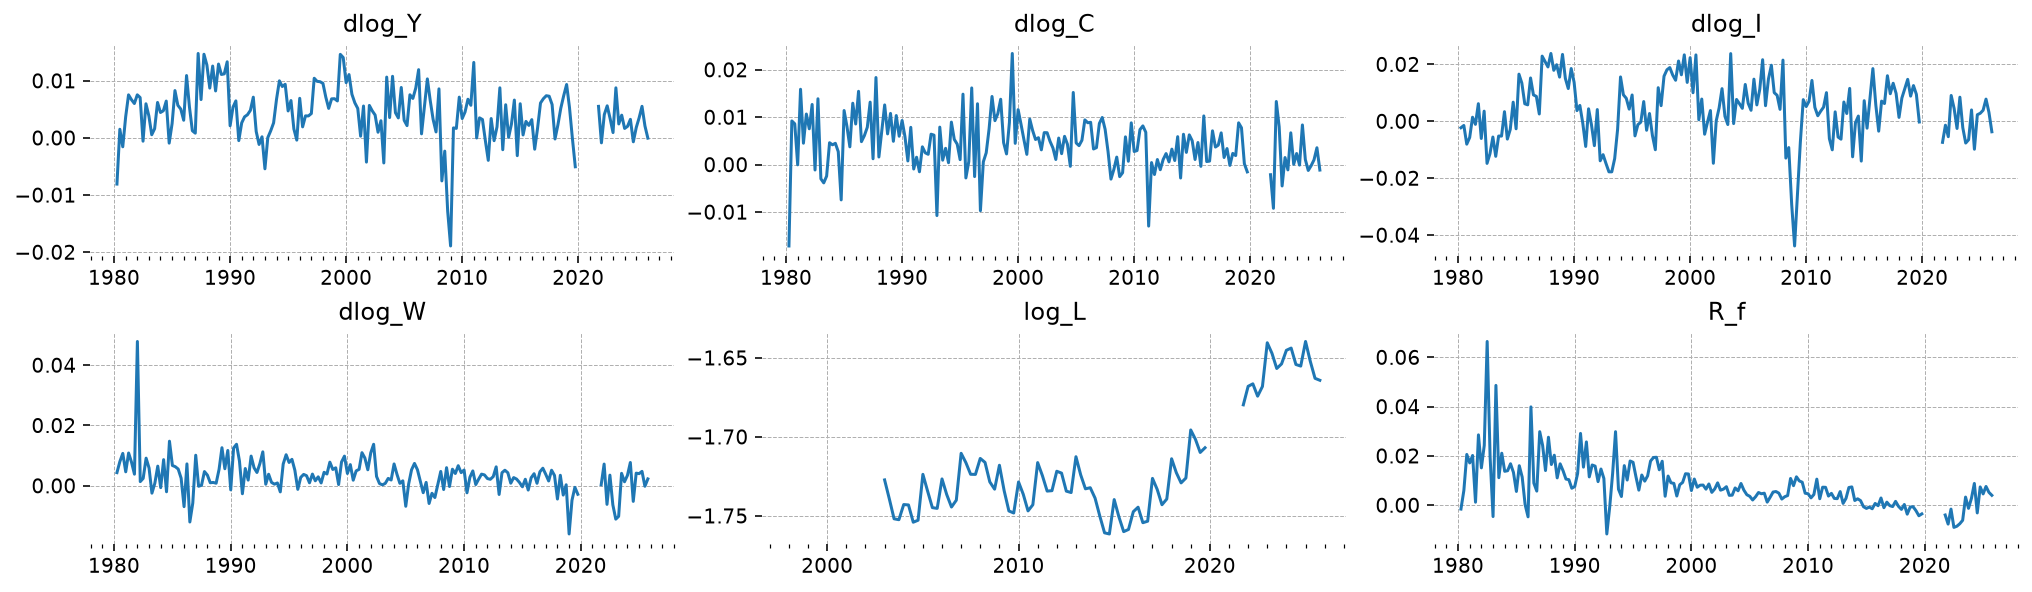

In [17]:
gp.plot_timeseries(df_obs_masked, n_cols=3, fig_kwargs={"figsize": (14, 4)});

## Fitting the Model

Estimation is a three-step routine: configure the state space, build the PyMC graph, then sample. We start with `ss_mod.configure(...)`, which freezes the structural choices the Kalman filter needs.

The two interesting options for our setup are **`observation_equations`** and **`ss_obs_intercept`**.

`observation_equations` is a dictionary mapping the name of an observed series (the LHS) to a GCN-style string expressing the observation in terms of latent model variables and parameters (the RHS). The LHS can be a brand-new name — it does not have to match any latent state. For the trending real-side variables we observe quarterly real growth rates, which the model writes as the log change in $X_t \cdot Z_t / Z_{t-1}$:

$$ \texttt{dlog\_Y} \;=\; \log\!\left(\frac{Y_t \, G_t}{Y_{t-1}}\right) $$

and similarly for $C$, $I$, $W$. For $L$ we observe the log of the stationary level. The state-space machinery parses each equation, linearises it around the steady state, and produces both the design-matrix row *and* the constant (intercept) term automatically — so the BGP growth rate $\log g_z$ ends up baked into the intercepts of the four `dlog_*` observables, and $\log L^{ss}$ becomes the intercept of `log_L`. No demeaning required.

`ss_obs_intercept` is a list of observed-state names that *don't* get an explicit observation equation — they're observed directly off a latent state, and we want the Kalman filter to use that state's steady-state value as the intercept. The real interest rate `r` is the only example here: the model latent `r[]` IS the observation (in level), and we want the intercept to be $r^{ss}$ on every parameter draw.

In [18]:
observation_equations = {
    "dlog_Y": "log(Y[] / Y[-1] * G[])",
    "dlog_C": "log(C[] / C[-1] * G[])",
    "dlog_I": "log(I[] / I[-1] * G[])",
    "dlog_W": "log(W[] / W[-1] * G[])",
    "log_L": "log(L[])",
}

# R_f has no observation equation: it is observed directly off the latent
# state, with the steady-state value used as the observation intercept.
ss_mod.configure(
    observed_states=list(df_obs.columns),
    observation_equations=observation_equations,
    ss_obs_intercept=["R_f"],
    measurement_error=list(df_obs.columns),
    mode="JAX",
    solver="scan_cycle_reduction",
    max_iter=13,
    use_adjoint_gradients=True,
    use_direct_lyapunov=False,
)

                    Model Requirements                    
                                                          
  Variable              Shape   Constraints   Dimensions  
 ──────────────────────────────────────────────────────── 
  Theta                 ()                          None  
  alpha                 ()                          None  
  beta                  ()                          None  
  delta                 ()                          None  
  g_z                   ()                          None  
  gamma_I               ()                          None  
  phi_H                 ()                          None  
  psi_z                 ()                          None  
  rho_A                 ()                          None  
  rho_I                 ()                          None  
  rho_Theta             ()                          None  
  rho_beta              ()                          None  
  rho_psi               ()                          None  
  sigma_L               ()                          None  
  sigma_epsilon_A       ()      Positive            None  
  sigma_epsilon_I       ()      Positive            None  
  sigma_epsilon_Theta   ()      Positive            None  
  sigma_epsilon_beta    ()      Positive            None  
  sigma_epsilon_psi     ()      Positive            None  
  sigma_epsilon_z       ()      Positive            None  
  error_sigma_dlog_Y    ()      Positive            None  
  error_sigma_dlog_C    ()      Positive            None  
  error_sigma_dlog_I    ()      Positive            None  
  error_sigma_dlog_W    ()      Positive            None  
  error_sigma_log_L     ()      Positive            None  
  error_sigma_R_f       ()      Positive            None  
                                                          
 These parameters should be assigned priors inside a PyMC 
  model block before calling the build_statespace_graph   
                         method.                          

### Building the PyMC graph

Every parameter listed by `configure()` needs to live as a PyMC random variable before we can call `build_statespace_graph`. The 14 structural parameters already have priors from the GCN, so `ss_mod.to_pymc()` registers them in one call. The remaining twelve standard-deviations (six structural shocks, six measurement errors) are not in the GCN by design — they're estimation-time choices — so we set them by hand.

The data is in growth-rate / log-level scale, so both kinds of $\sigma$ live somewhere around the 0.001–0.05 band; a `maxent(Gamma, lower=0.001, upper=0.05)` prior pins 99% of the prior mass inside that range.

In [19]:
with pm.Model(coords=ss_mod.coords) as rbc_growth_pm:
    ss_mod.to_pymc()
    prior_dict = ss_mod.param_priors.copy()

    # Theta sets the steady-state level of labour and has no GCN prior.  It is
    # only weakly identified: L_ss is a joint function of Theta, sigma_L and
    # alpha, so a loose prior leaves a ridge the sampler cannot traverse.  Pin
    # it with a tight Normal centred on the value implied by the observed
    # labour mean -- Theta ~ 157 gives L_ss = exp(mean(log_L)) ~ 0.18.
    d = pz.Normal(mu=157.0, sigma=10.0)
    prior_dict["Theta"] = d
    d.to_pymc("Theta")

    for shock in ss_mod.shock_names:
        d = pz.maxent(pz.Gamma(), lower=0.001, upper=0.05, plot=False)
        prior_dict[f"sigma_{shock}"] = d
        d.to_pymc(f"sigma_{shock}")

    for obs in ss_mod.error_states:
        d = pz.maxent(pz.Gamma(), lower=0.001, upper=0.05, plot=False)
        prior_dict[f"error_sigma_{obs}"] = d
        d.to_pymc(f"error_sigma_{obs}")

    ss_mod.build_statespace_graph(
        data=df_obs_masked[list(ss_mod.observed_states)],
    )

In [20]:
import nutpie as ntp

initial_points = {k: v + 1e-7 for k, v in ss_mod.param_dict.items() if k in [x.name for x in rbc_growth_pm.basic_RVs]}
initial_points["Theta"] = 100.0
ntp_mod = ntp.compile_pymc_model(
    rbc_growth_pm,
    backend="jax",
    gradient_backend="jax",
    freeze_model=True,
    default_initialization_strategy="prior",
    jitter_rvs=None,
    initial_points=initial_points,
)

In [21]:
from jax import nn

idata = ntp.sample(
    (
        ntp_mod.with_transform_adapt(
            verbose=False,
            show_progress=False,
            activation=nn.swish,
        )
    ),
    tune=2000,
    draws=500,
    chains=4,
    adaptation="flow",
)

# nutpie's raw output carries no data groups, and post-estimation sampling recovers the fit from them
data_groups = pm.sample_prior_predictive(draws=1, model=rbc_growth_pm, var_names=[])
idata["observed_data"] = data_groups["observed_data"]
idata["constant_data"] = data_groups["constant_data"]

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2500,0,0.72,7
,2500,0,0.71,7
,2500,2,0.63,7
,2500,0,0.71,7


Sampling: []


## Posterior Diagnostics

Once sampling finishes, the first stop is convergence: have the chains mixed, have they explored the posterior, and is the effective sample size large enough to take the summary numbers seriously? For a six-shock DSGE with 26 estimated parameters, trace plots and `az.summary` are the minimum sanity check.

We split the parameter list into three logical groups: the **structural / deep parameters** (the 14 entries with GCN priors), the **shock standard deviations** (`sigma_epsilon_*`), and the **measurement-error standard deviations** (`error_sigma_*`). Posterior shapes for each group tell different stories, so it pays to look at them separately.

In [22]:
deep_params = list(ss_mod.param_dict.keys())
shock_sigmas = [f"sigma_{s}" for s in ss_mod.shock_names]
error_sigmas = [f"error_sigma_{s}" for s in ss_mod.error_states]

az.summary(idata, var_names=deep_params + shock_sigmas + error_sigmas, round_to=3)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Theta,150.193,10.554,133.486,166.964,4715.552,1690.185,1.003,0.154,0.293
alpha,0.214,0.021,0.181,0.247,4898.186,1515.237,1.002,0.000,0.001
beta,0.994,0.002,0.991,0.996,4994.232,1237.784,0.999,0.000,0.000
delta,0.036,0.010,0.022,0.055,5318.378,1573.032,1.003,0.000,0.000
g_z,1.004,0.000,1.003,1.004,6127.992,1500.508,1.003,0.000,0.000
gamma_I,7.860,1.053,6.212,9.626,4742.336,1534.135,1.001,0.016,0.030
phi_H,0.821,0.069,0.699,0.917,3363.426,1304.129,1.007,0.001,0.002
psi_z,0.254,0.093,0.118,0.424,5320.929,1293.595,1.000,0.001,0.003
rho_A,0.932,0.037,0.865,0.979,4417.802,1393.697,1.002,0.001,0.001
rho_I,0.772,0.080,0.633,0.887,5150.303,1506.180,1.004,0.001,0.002


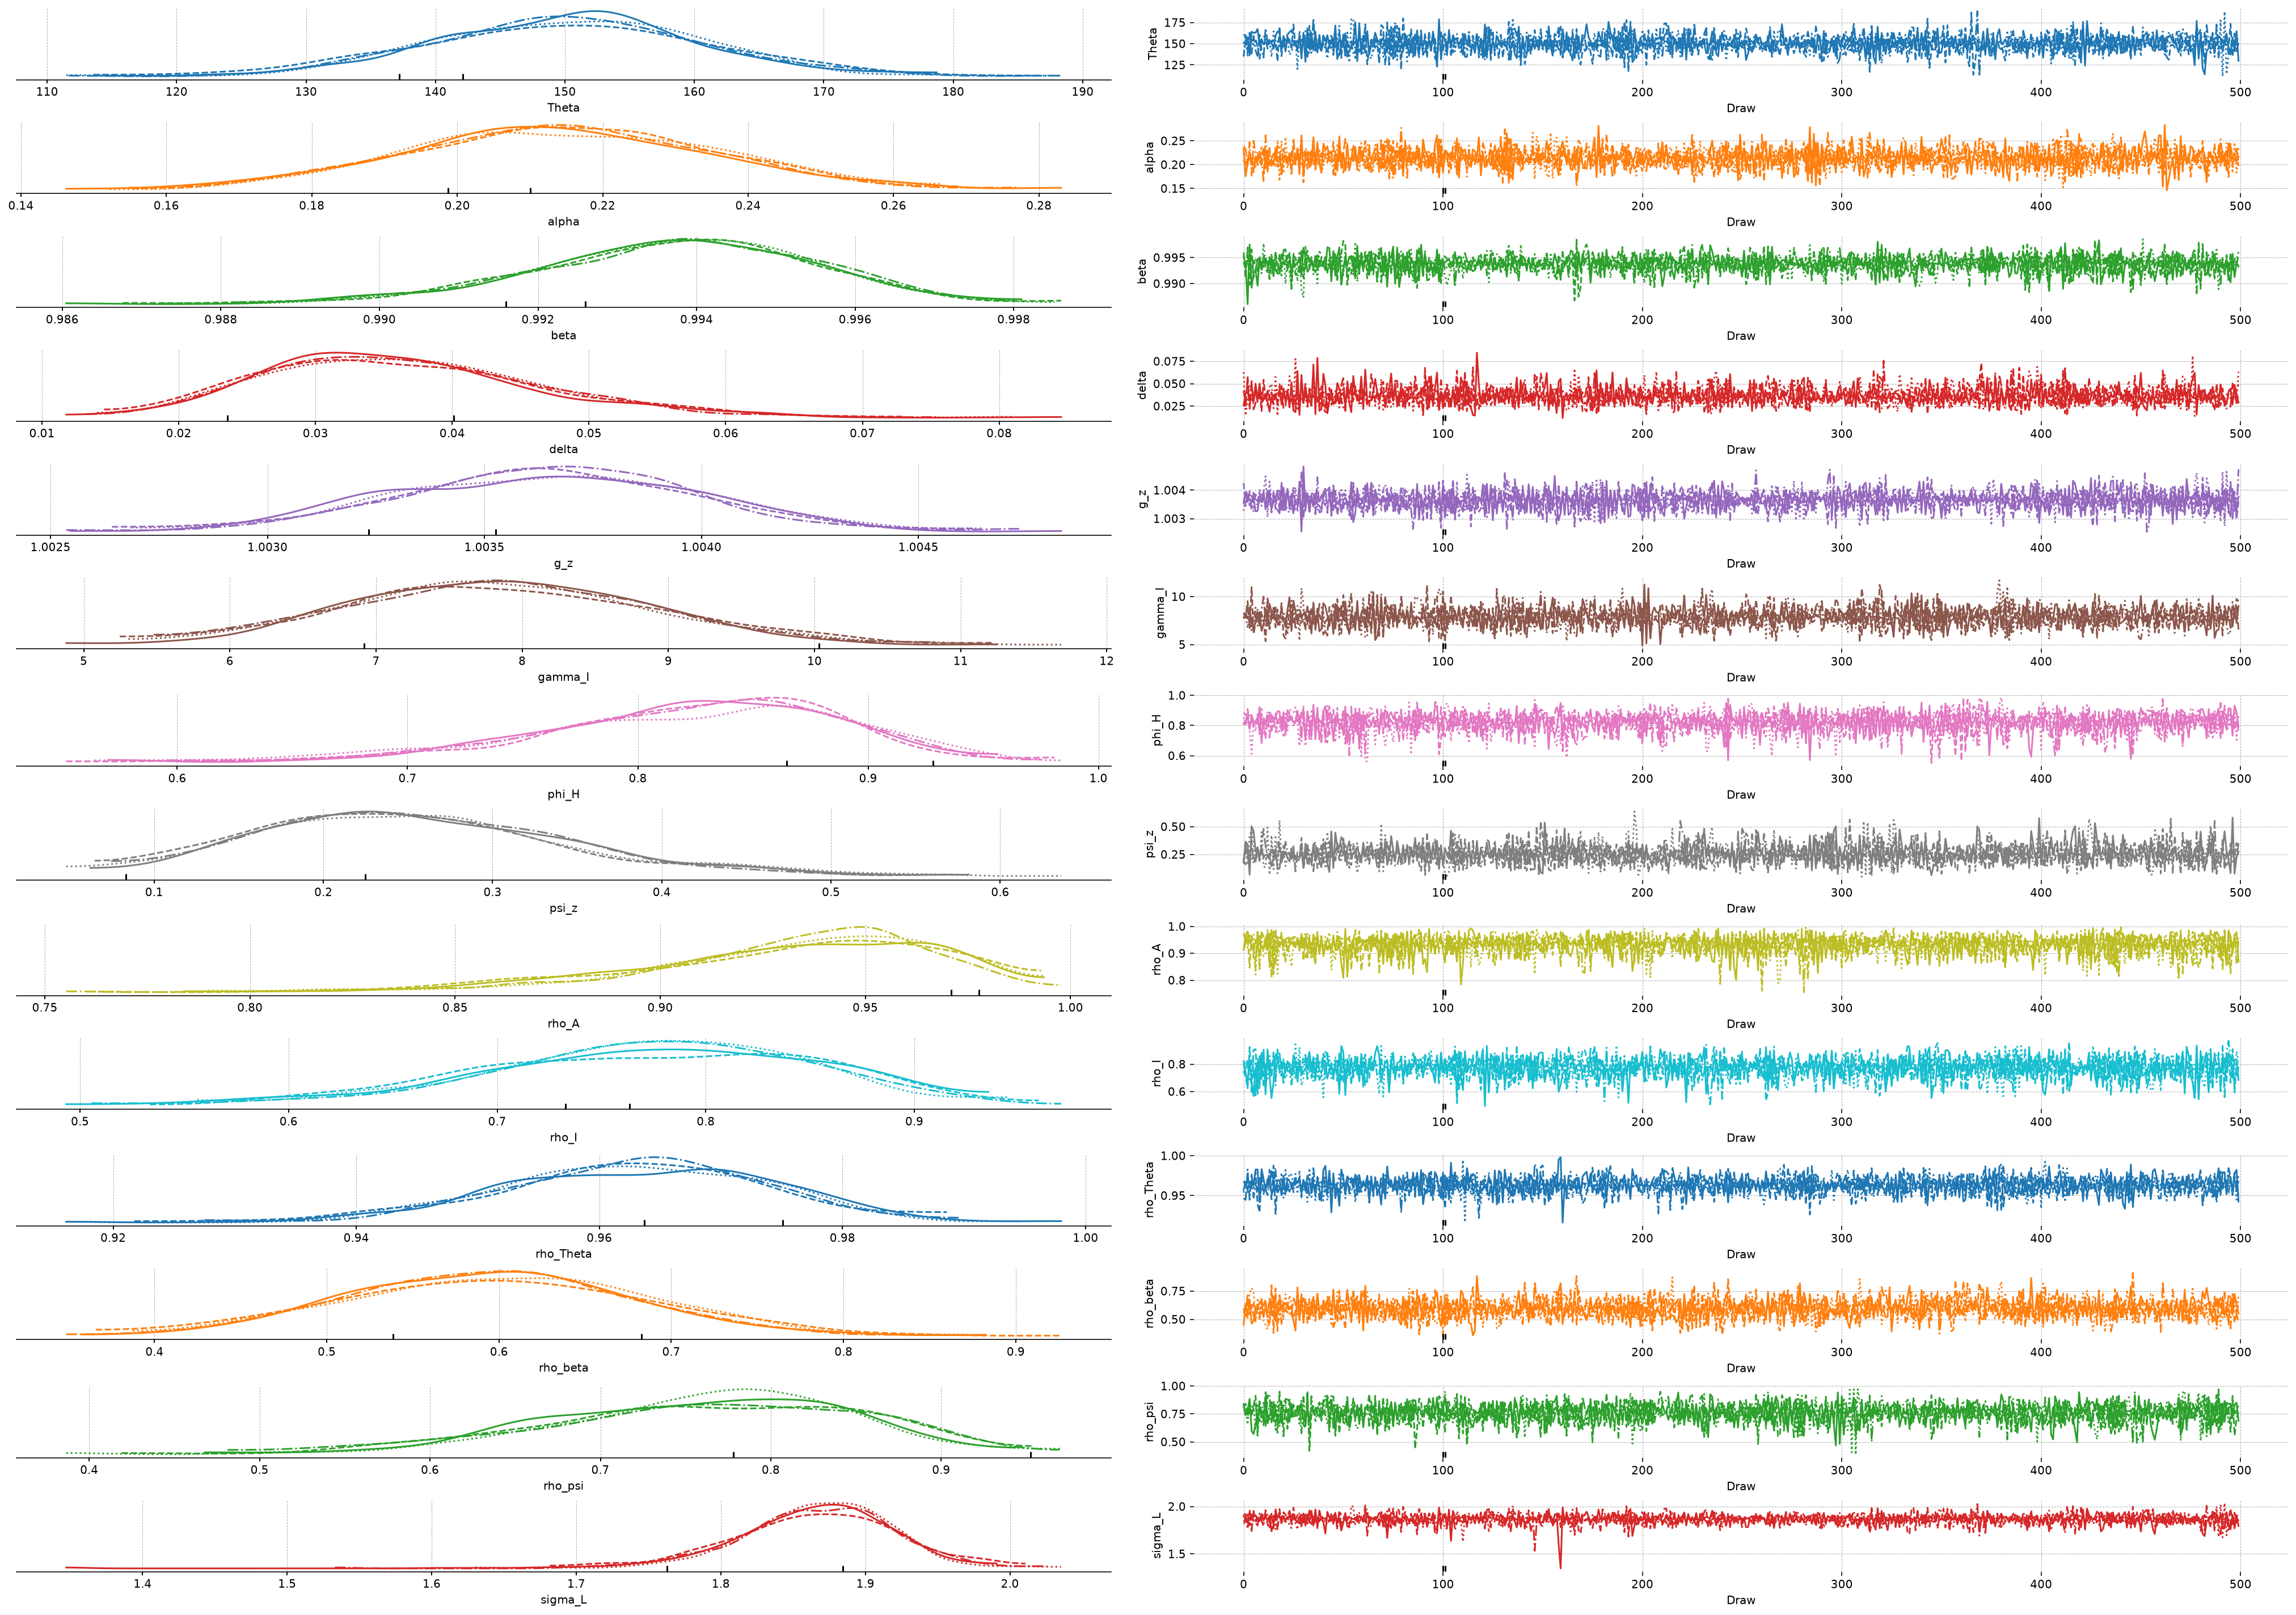

In [23]:
az.plot_trace_dist(idata, var_names=list(deep_params));

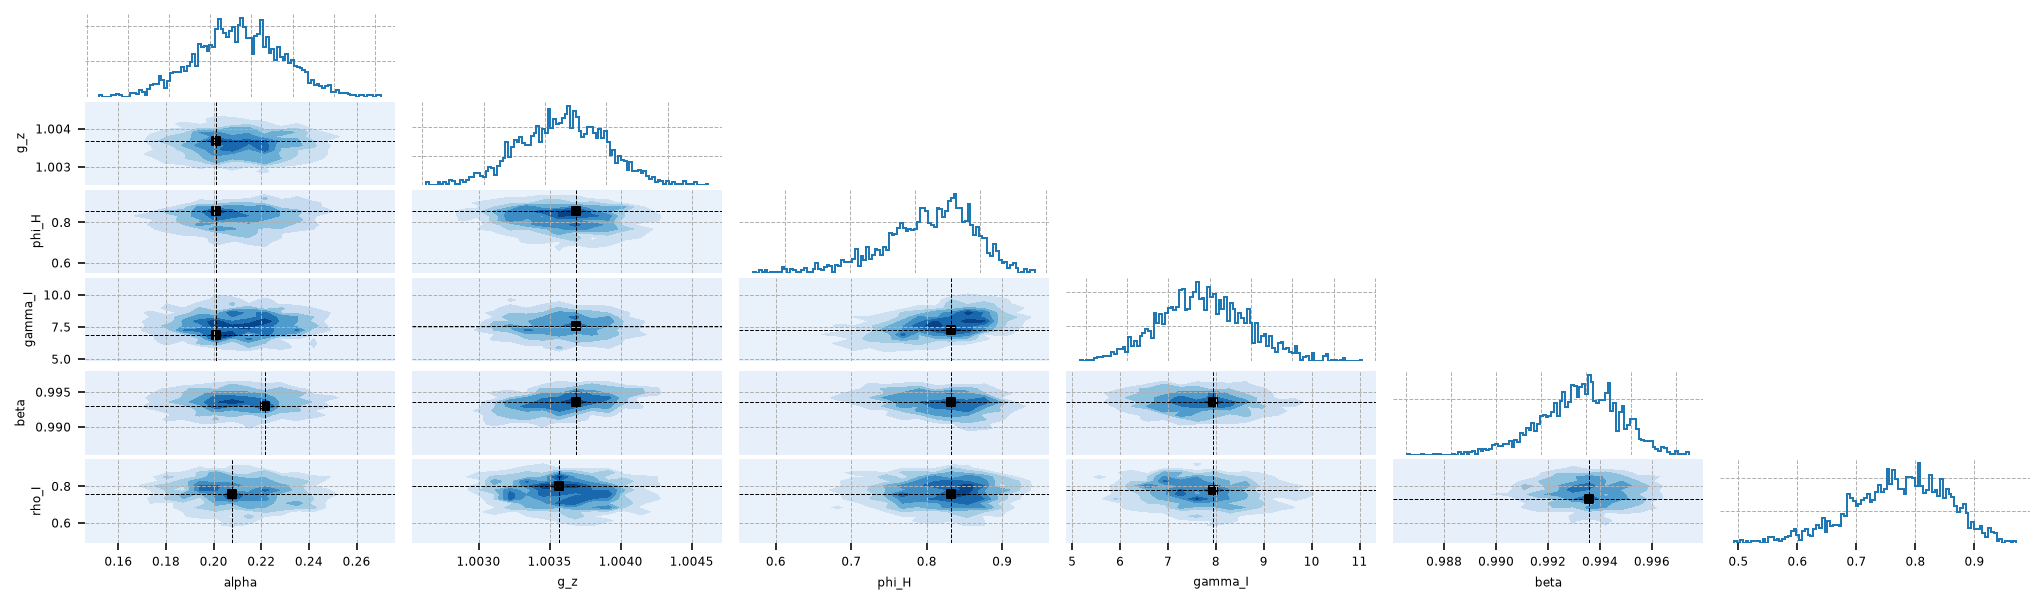

In [24]:
gp.plot_corner(idata, var_names=["alpha", "g_z", "phi_H", "gamma_I", "beta", "rho_I"]);

### Posterior vs. prior

The structural posteriors are most informative when overlaid on the priors that generated them. A posterior that hugs its prior means the data did not move the parameter (it is weakly identified); a posterior that is narrow and far from the prior mode means the data has a lot to say about it. We use the same `prior_dict` we built when configuring the PyMC model so the two distributions are plotted on a common scale.

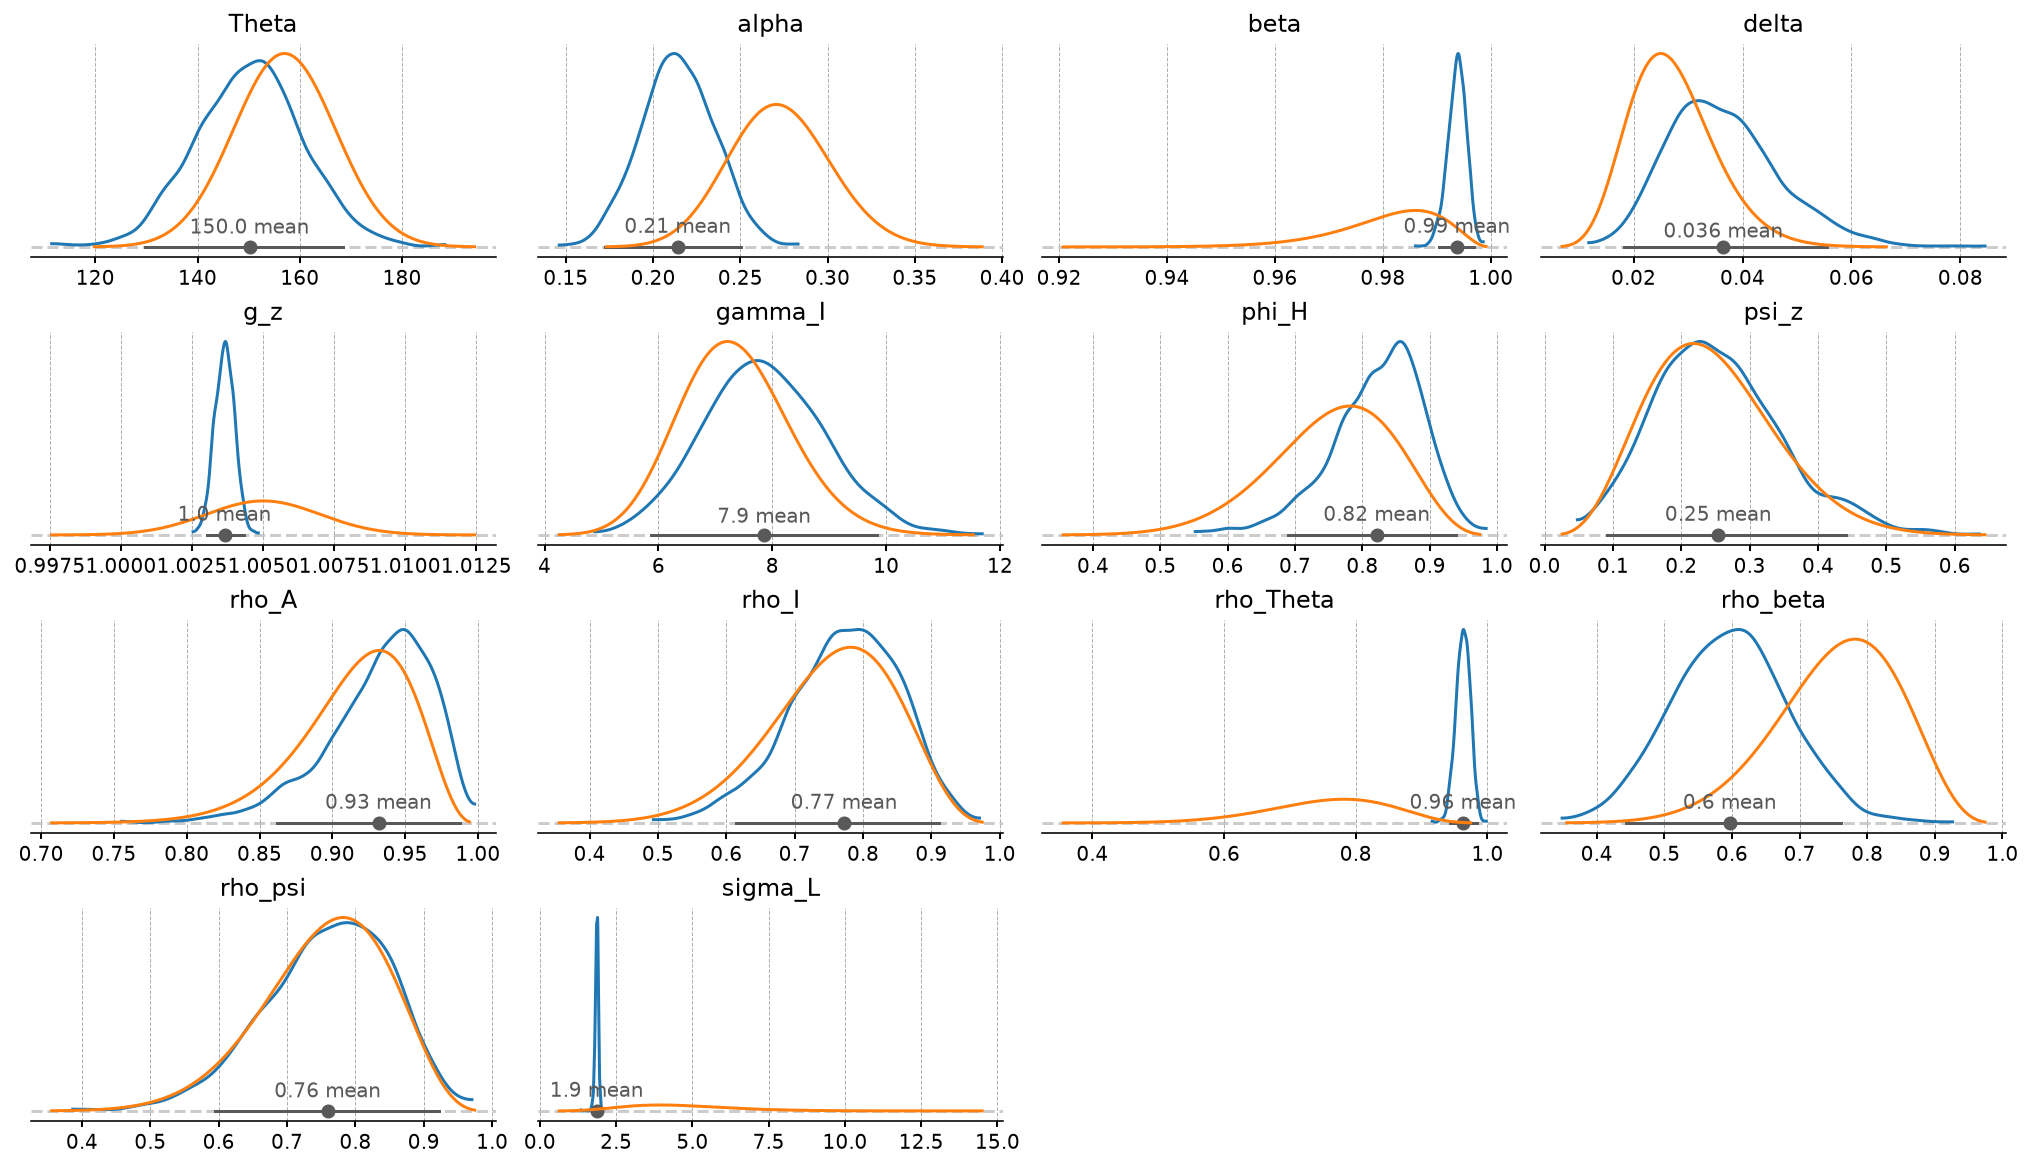

In [25]:
gp.plot_posterior_with_prior(
    idata, var_names=deep_params, prior_dict=prior_dict, n_cols=4, fig_kwargs={"figsize": (14, 8)}
);

### Shock and measurement-error scales

The six $\sigma_{\varepsilon,\cdot}$ tell us how big the structural innovations are. The six measurement-error $\sigma$s tell us, for each observable, how much the Kalman filter is allowed to attribute to "noise" rather than to model dynamics. Series with a *large* posterior measurement-error are series the model is having to give up on — the structure cannot reproduce them and the filter is reaching for white-noise slack instead.

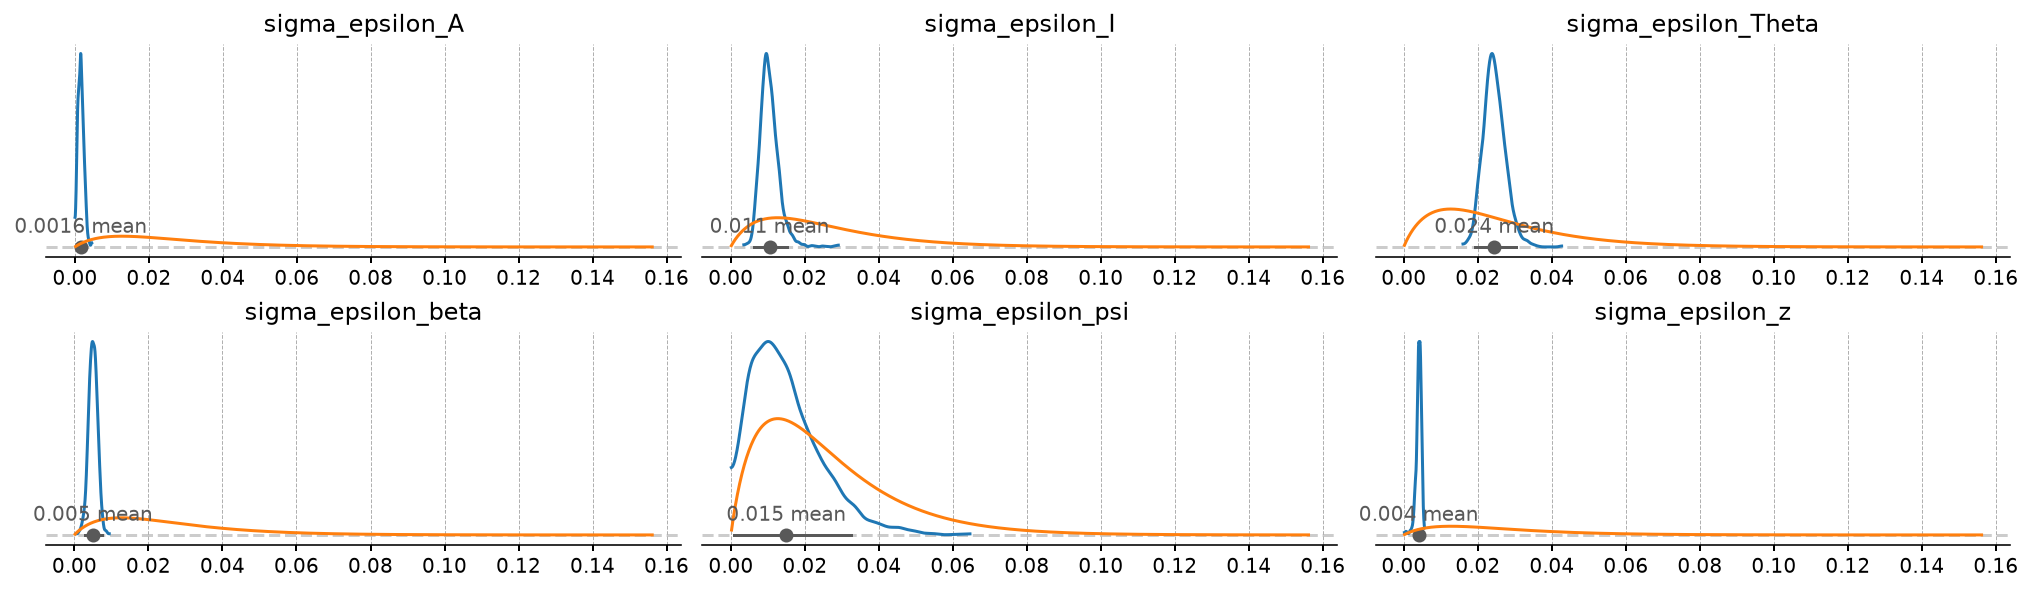

In [26]:
gp.plot_posterior_with_prior(
    idata, var_names=shock_sigmas, prior_dict=prior_dict, n_cols=3, fig_kwargs={"figsize": (14, 4)}
);

## Smoothed Latent States

The Kalman smoother infers the path of every latent state — the stationary cycle, the trend growth rate, the AR(1) shock processes — conditional on the entire observed sample and the posterior draws of the parameters. Two outputs are usually most informative:

1. **Smoothed observables.** For each observed series, the model's best guess of where the *signal* (data minus measurement error) actually was. Tight match means the model thinks it understood that series; loose match means it had to absorb structural mis-specification into measurement error.
2. **Smoothed latent shocks.** The four taste / friction shock states ($\beta_t$, $\Theta_t$, $\xi^I_t$, $\xi^\psi_t$) plus the two technology states ($A_t$, $G_t$). These are the structural drivers the model attributes to every wiggle in the data.

`ss_mod.sample_conditional_posterior` runs the smoother on every posterior draw and stores the filtered, predicted, and smoothed paths back into an `InferenceData`. `gp.plot_kalman_filter` is the canonical visualisation.

In [27]:
latent_states = ss_mod.sample_conditional_posterior(idata, random_seed=rng, compile_kwargs={"mode": "NUMBA"})

Sampling: [filtered_posterior, filtered_posterior_observed, predicted_posterior, predicted_posterior_observed, smoothed_posterior, smoothed_posterior_observed]


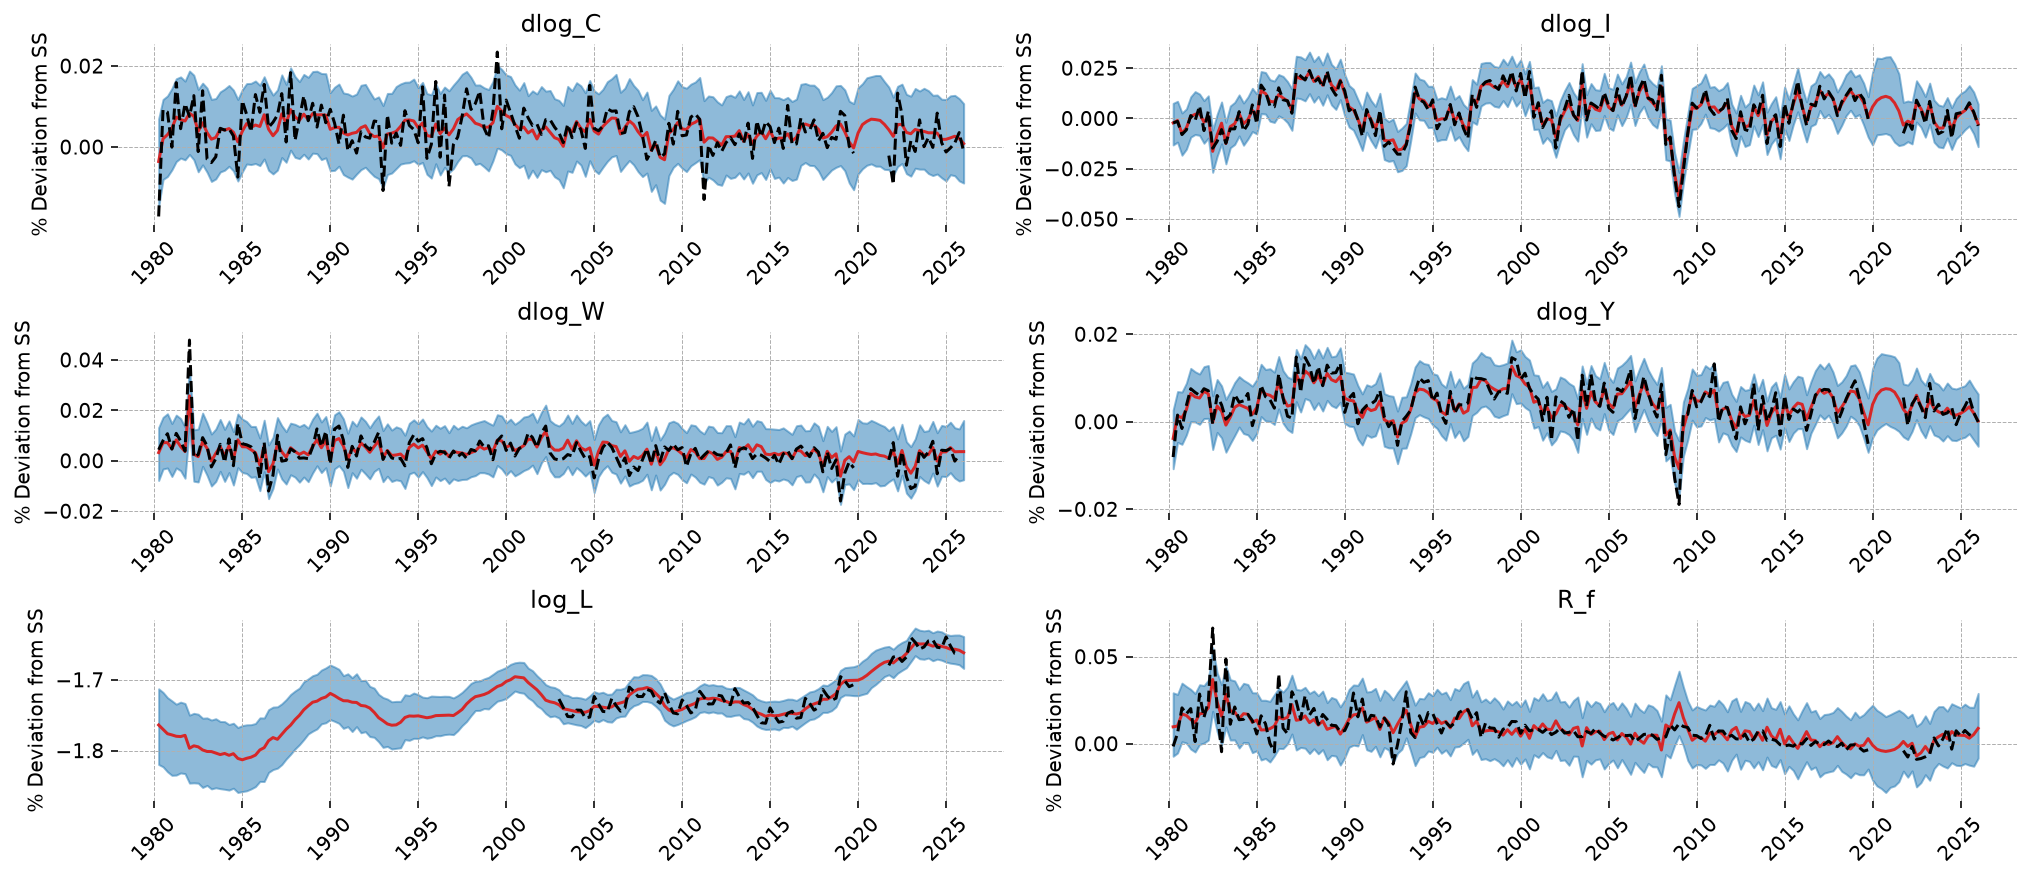

In [28]:
gp.plot_kalman_filter(
    idata=latent_states,
    data=df_obs_masked,
    vars_to_plot=["dlog_C", "dlog_I", "dlog_W", "dlog_Y", "log_L", "R_f"],
    kalman_output="smoothed",
    n_cols=2,
    figsize=(14, 6),
    observed=True,
);

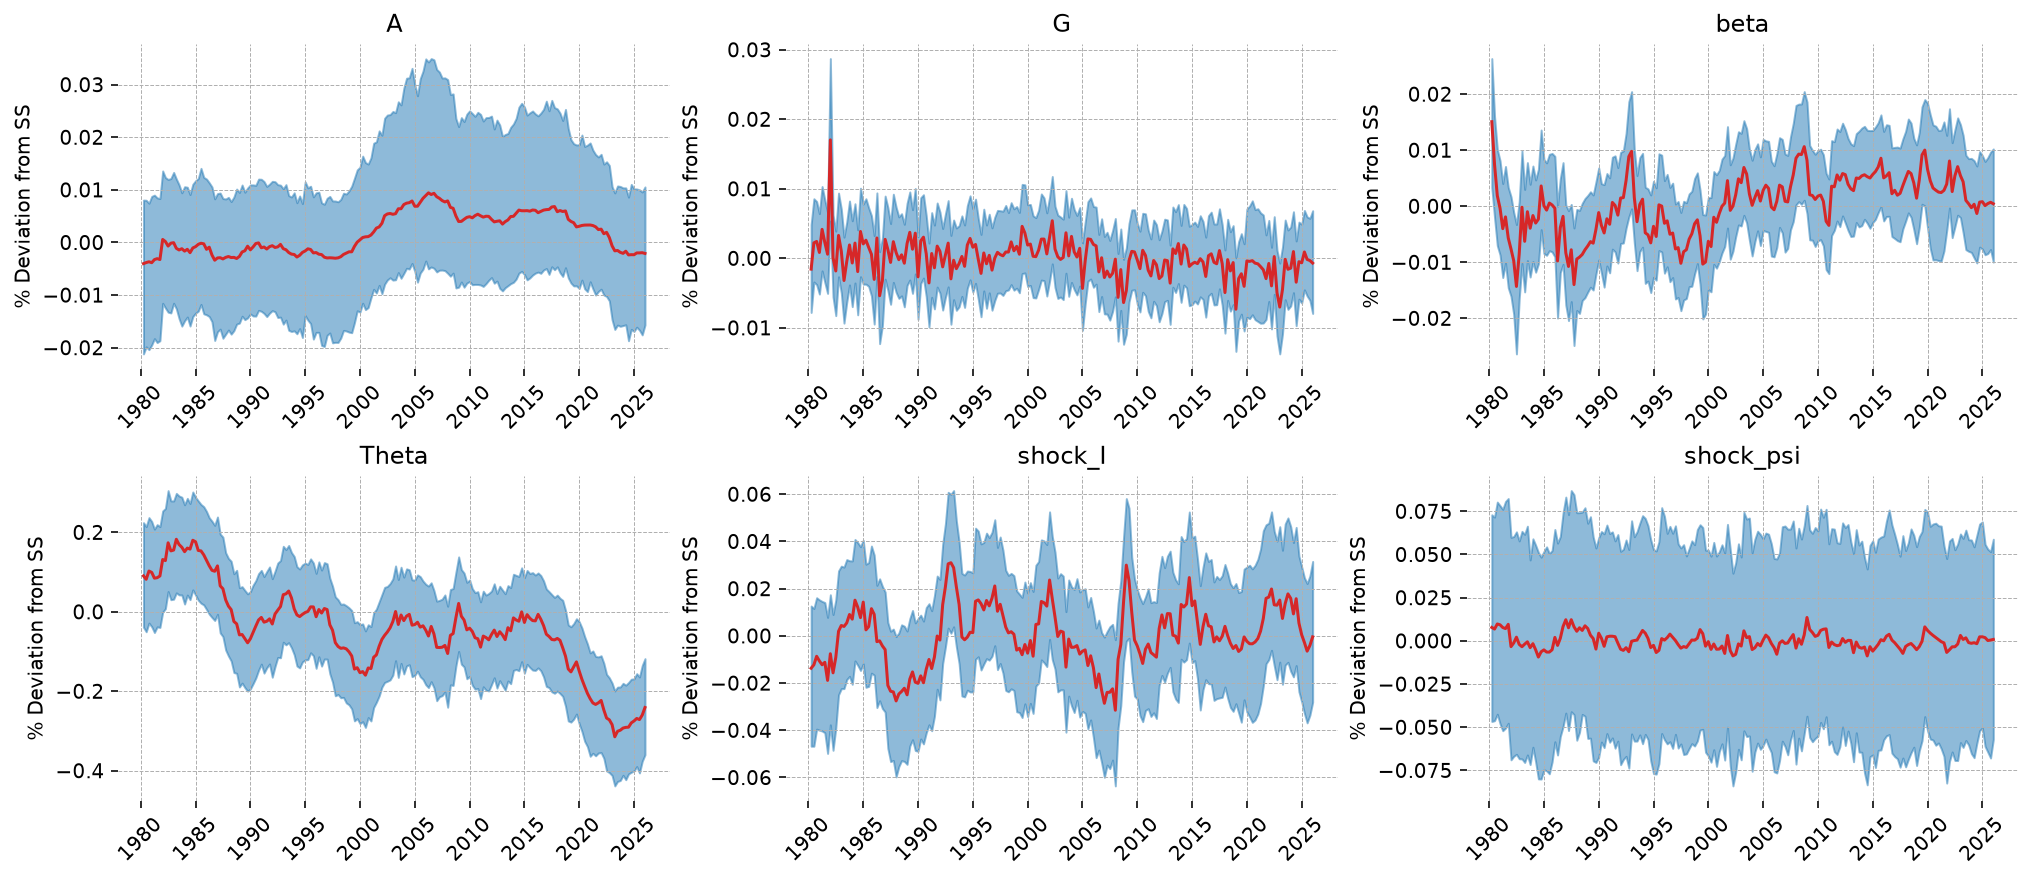

In [29]:
gp.plot_kalman_filter(
    idata=latent_states,
    data=df_obs,
    kalman_output="smoothed",
    vars_to_plot=["A", "G", "beta", "Theta", "shock_I", "shock_psi"],
    n_cols=3,
    figsize=(14, 6),
);

## Forecasting

The state-space machinery makes forecasting essentially free: given any starting time in the sample (and the joint posterior over parameters and states), it propagates the linear transition forward and samples observation paths. For our growth model, the forecasts are **already in the right units** — the four `dlog_*` paths come out as quarterly real growth rates and `log_L`, `r` come out in their observation scales. No retrending step is needed because the model's own $g_z$ and $\varepsilon_z$ trend dynamics are baked into the prediction.

Below we forecast forty quarters (ten years) from five quarters before the end of the sample, so we can compare the in-sample tail to the model's mean / 95% credible interval.

In [30]:
forecast = ss_mod.forecast(idata, periods=40, start=df_obs.index[-1], random_seed=rng)

Sampling: [forecast_combined]


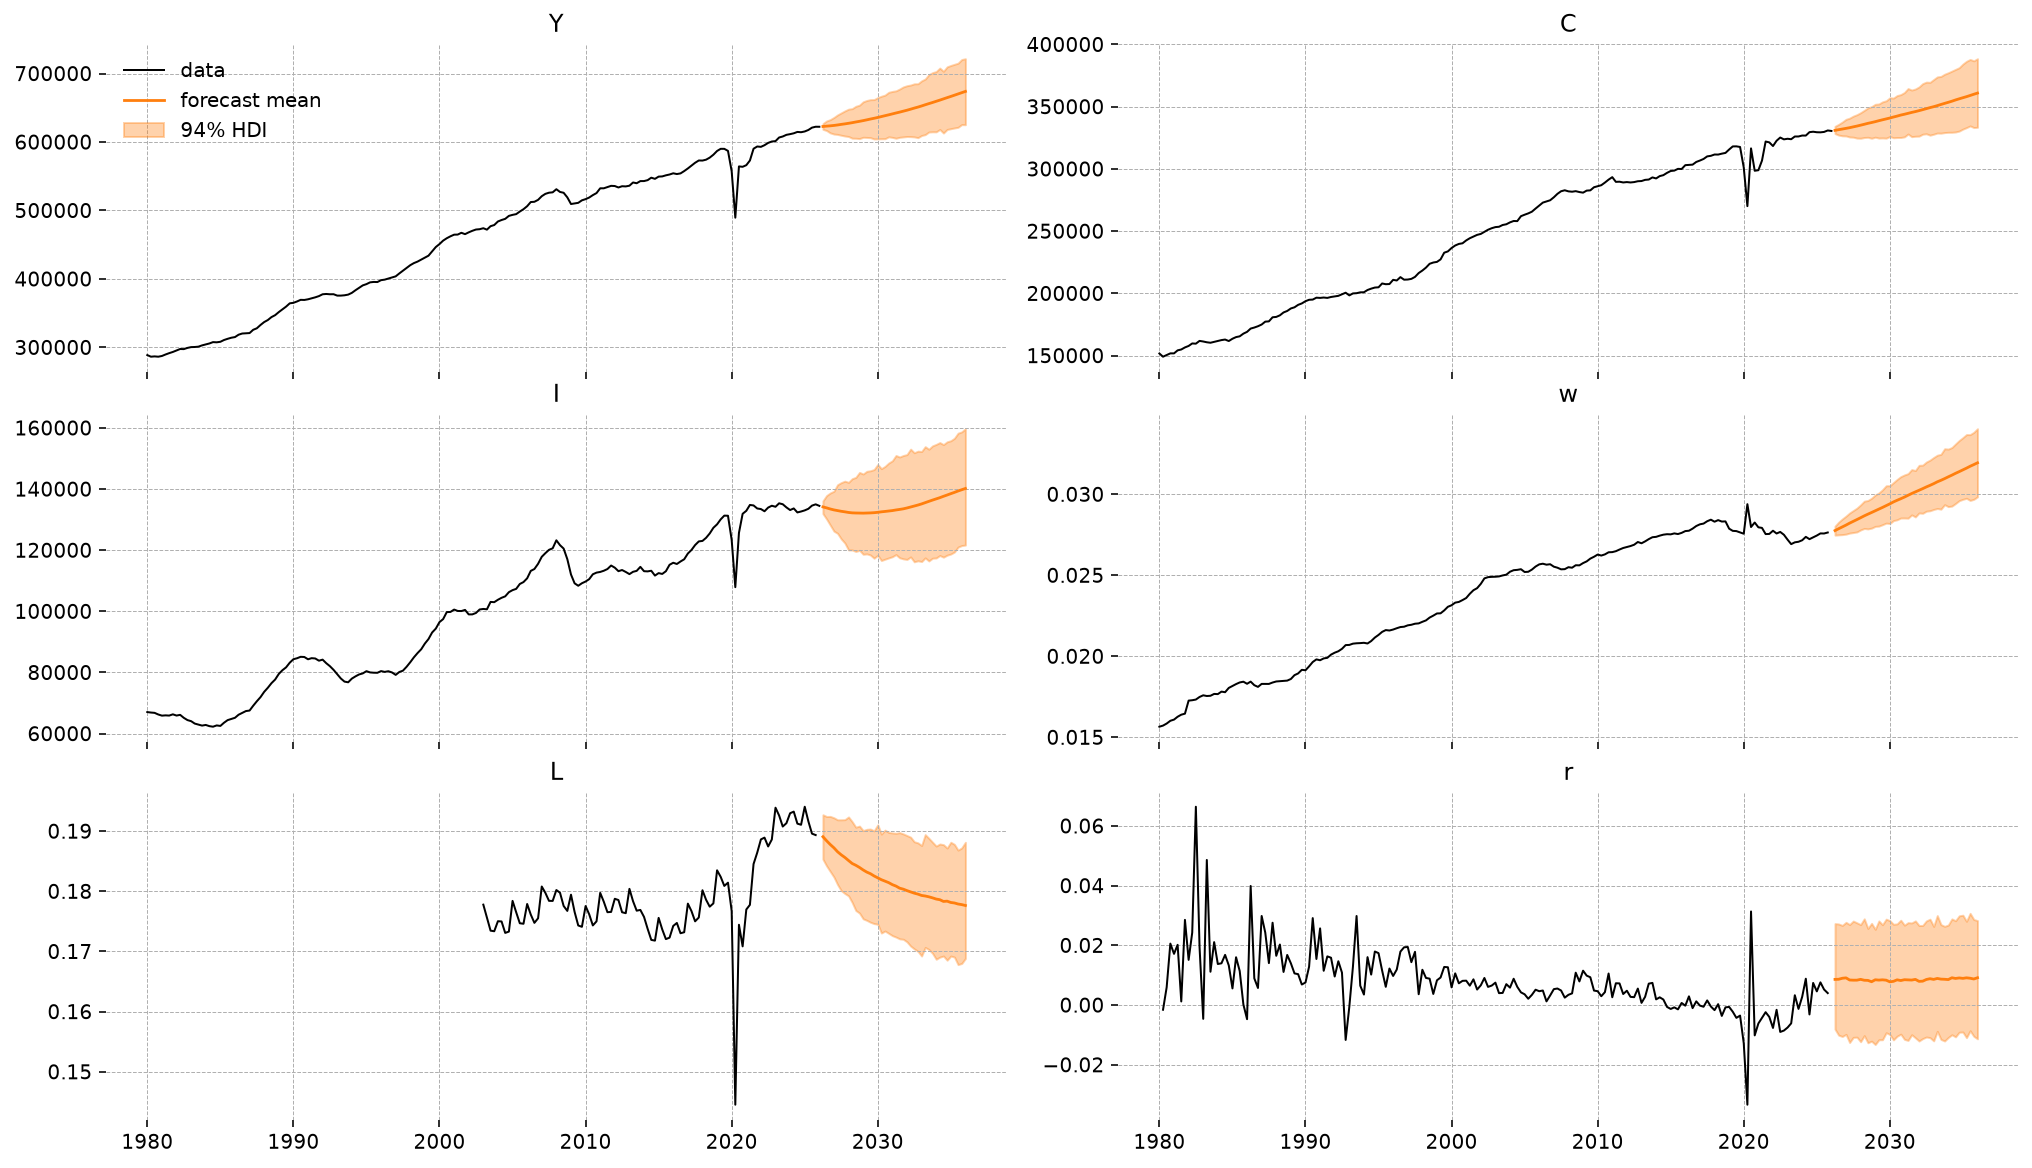

In [31]:
# Each observable maps to a raw series in `df` and an inverse transform:
#   "growth" -- data is a log-difference; re-trend by anchoring at the last
#               observed level and cumulating:  X_T * exp(cumsum(dlog)).
#   "log"    -- data is a log level; invert with exp.
#   "level"  -- data is already in model units; identity.
obs_meta = {
    "dlog_Y": ("Y", "growth"),
    "dlog_C": ("C", "growth"),
    "dlog_I": ("I", "growth"),
    "dlog_W": ("w", "growth"),
    "log_L": ("L", "log"),
    "R_f": ("r", "level"),
}

fc = forecast.forecast_observed  # (chain, draw, time, observed_state)
fc_time = fc.coords["time"].values
start = df_obs.index[-1]

fig, axes = plt.subplots(3, 2, figsize=(14, 8), sharex=True, layout="constrained")

for ax, name in zip(axes.flat, ss_mod.observed_states, strict=False):
    raw_col, kind = obs_meta[name]
    series = fc.sel(observed_state=name)

    # Invert the preprocessing transform *per draw*, before taking any
    # summaries -- cumulating must happen draw-by-draw, not on the HDI bounds.
    if kind == "growth":
        level = df[raw_col].ffill().loc[start] * np.exp(series.cumsum(dim="time"))
    elif kind == "log":
        level = np.exp(series)
    else:
        level = series

    mu = level.mean(dim=["chain", "draw"])
    hdi = az.hdi(level)

    data = df[raw_col]
    ax.plot(data.index, data.values, color="black", lw=1.0, label="data")
    ax.plot(fc_time, mu.values, color="tab:orange", lw=1.4, label="forecast mean")
    ax.fill_between(fc_time, *hdi.values.T, color="tab:orange", alpha=0.35, label="94% HDI")
    ax.set_title(raw_col)

axes.flat[0].legend(frameon=False)
plt.show()

# Authors

- Created by Jesse Grabowski, May 21, 2026
- Updated by Jesse Grabowski, September 14, 2026


# Watermark

In [32]:
%load_ext watermark
%watermark -n -u -v -iv -m -w

Last updated: Thu, 17 Sep 2026

Python implementation: CPython
Python version       : 3.12.14
IPython version      : 9.17.1

Compiler    : Clang 21.1.8 
OS          : Darwin
Release     : 25.6.0
Machine     : arm64
Processor   : arm
CPU cores   : 14
Architecture: 64bit

arviz      : 1.3.0
arviz_plots: 1.3.1
gEconpy    : 2.2.1.dev37+g2d175e5c4.d20260916
jax        : 0.10.2
kuznets    : 1.1.0
matplotlib : 3.11.1
numpy      : 2.4.6
nutpie     : 0.16.11
pandas     : 3.0.5
preliz     : 0.28.0
pymc       : 6.3.1
pytensor   : 3.3.0

Watermark: 2.6.0

